**Autor:** Santiago Jerez  
**Materia:** Metodología de la Opinión Pública  
**Fecha:** Noviembre de 2024 (con datos de Octubre 2023)  

Este informe analiza el comportamiento electoral en la ciudad de Rosario a partir de datos de encuesta georreferenciada.  
El objetivo es explorar la relación entre **género, edad y voto a distintos espacios políticos**, utilizando herramientas de análisis cuantitativo (Python, pandas, statsmodels, scikit-learn) y visualización geoespacial (geopandas, folium).  

---

## Resumen Ejecutivo
 - **Juntos por el Cambio** posee la mayor intención de voto con 24,3%, seguido por el **Frente de Todos** con 22,7% y **La Libertad Avanza** con 15,3%.
 - Al momento de la encuesta, **el 20,1% de los entrevistados** se manifestó indeciso o sin intenciones de votar a algún político.
 - La intención de voto de los habitantes de Rosario *no parecería estar influenciada* por factores socioeconómicos clásicos. Destacan el aumento de las probabilidades de *votar a LLA entre los hombres* y de *votar al FIT en el segmento más joven*.
- **Implicancia estratégica:** la combinación de voto fragmentado e indecisos sugiere que la definición final del electorado podía depender de la campaña y del clima coyuntural más que de perfiles sociodemográficos.
- **Limitación:** los modelos explicativos muestran bajo poder predictivo, lo que indica que variables contextuales y de percepción política no capturadas en el cuestionario probablemente hayan jugado un rol central.

## Datos y Alcance

- **Universo:** residentes de la ciudad de Rosario, mayores de 16 años con derecho a voto.  
- **Muestra:** encuesta georreferenciada realizada en los días previos a las elecciones generales de octubre 2023.  
- **Tamaño muestral:** n = 372 casos válidos (completar).  
- **Variables clave:** intención de voto, género, edad y distrito de residencia. Además, se incorporaron *variables socioeconómicas agregadas desde datos censales* (nivel educativo, condiciones habitacionales, etc.) georreferenciadas al domicilio del encuestado.
- **Cobertura geográfica:** todos los distritos de Rosario.  
- **Trabajo de campo:** Octubre 2023. Procesamiento y análisis en noviembre de 2024.  
- **Limitaciones iniciales:**  
  - Posible infrarrepresentación de ciertos segmentos (ej. jóvenes 16–24, adultos 56 y más).  
  - No se incluyeron variables de percepción política ni socioeconómicas detalladas (ingresos, ocupación), lo que reduce el poder explicativo de los modelos.  
  - Los resultados deben interpretarse como descriptivos y exploratorios, sin inferir causalidad.  

## Metodología

- **Preparación de datos:** se trabajó con una base de microdatos de la encuesta georreferenciada en Rosario (octubre 2023). Se filtró la base de datos en las latitudes y longitudes de la ciudad para eliminar casos mal referenciados geograficamente.  

- **Enriquecimiento con datos censales:** a cada observación se le incorporaron variables socioeconómicas de contexto (nivel educativo promedio, condiciones habitacionales, etc.) a partir del cruce con información del Censo. Estas variables fueron vinculadas de manera geográfica al domicilio declarado o lugar de entrevista, funcionando como aproximaciones contextuales y no como características individuales.  

- **Análisis descriptivo:** se calcularon proporciones de intención de voto totales y segmentadas por género y edad, además de visualizar la distribución espacial mediante mapas georreferenciados.  

- **Modelos de regresión:** se estimaron modelos logísticos para explorar la relación entre variables sociodemográficas y la probabilidad de votar por determinados partidos (LLA, FIT, etc.). Los resultados se interpretan en términos de dirección y significancia de los coeficientes, teniendo en cuenta el bajo poder explicativo de los modelos (Pseudo R² bajos).  

- **Limitaciones metodológicas:** el análisis es exploratorio, no busca establecer causalidad. Las variables socioeconómicas agregadas a partir del Censo funcionan como indicadores de contexto y pueden no reflejar condiciones individuales. Asimismo, la ausencia de variables de percepción política reduce la capacidad explicativa de los modelos.

In [278]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import matplotlib.cm as cm
from shapely.geometry import Point
import folium
from IPython.display import display, HTML
import contextily as ctx
import matplotlib.patches as mpatches
from shapely.geometry import shape
import json
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

In [279]:
df=pd.read_csv("https://raw.githubusercontent.com/Sajerez/Portfolio/refs/heads/main/Encuesta%20Rosario/Datasets/dataset%20filtrado.csv")
secciones=gpd.read_file('https://raw.githubusercontent.com/Sajerez/Portfolio/refs/heads/main/Encuesta%20Rosario/Datasets/secciones_catastrales.gml')
distritos=gpd.read_file('https://raw.githubusercontent.com/Sajerez/Portfolio/refs/heads/main/Encuesta%20Rosario/Datasets/distritos_descentralizados.gml')
barrios=gpd.read_file('https://github.com/Sajerez/Portfolio/raw/refs/heads/main/Encuesta%20Rosario/Datasets/barrios.gml')
estratos=gpd.read_file('https://raw.githubusercontent.com/Sajerez/Portfolio/refs/heads/main/Encuesta%20Rosario/Datasets/Estratificaci%C3%B3n%20de%20radios%20censales%20-%20Rosario.csv')
niveleducativo=gpd.read_file('https://raw.githubusercontent.com/Sajerez/Portfolio/refs/heads/main/Encuesta%20Rosario/Datasets/Indicadores%20de%20personas.%20Radios%2C%202022%20-%20Rosario.csv')
pobreza=gpd.read_file('https://raw.githubusercontent.com/Sajerez/Portfolio/refs/heads/main/Encuesta%20Rosario/Datasets/Pobreza%20Cr%C3%B3nica%20x%20Radio%20Censal%20-%20Rosario.csv')

In [280]:
#Creación del geodataframe
geometry = [Point(xy) for xy in zip(df['Coord1__Longitude'], df['Coord1__Latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry)
gdf.set_crs('EPSG:4326', inplace=True)
union=gpd.sjoin(gdf, barrios, how='inner', predicate='within')
unionseccion=gpd.sjoin(gdf, secciones, how='inner', predicate='within')
uniondistritos=gpd.sjoin(gdf, distritos, how='inner', predicate='within')

In [281]:
#Filtrado de datos para Rosario
lat_min_valid = -33.0
lat_max_valid = -32.85
lon_min_valid = -60.790
lon_max_valid = -60.6
gdf = gdf[
    (gdf['Coord1__Latitude'] >= lat_min_valid) &
    (gdf['Coord1__Latitude'] <= lat_max_valid) &
    (gdf['Coord1__Longitude'] >= lon_min_valid) &
    (gdf['Coord1__Longitude'] <= lon_max_valid)
]

In [282]:
#Comenzamos agregando un mapa interactivo para ver la ubicación de los puntos 
m = folium.Map(location=[-32.9, -60.7], zoom_start=13)
for _, row in gdf.iterrows():
    folium.Marker(
        location=[row['Coord1__Latitude'], row['Coord1__Longitude']],
        popup=(
            f"EDAD: {row['EDAD']}<br>"
            f"GENERO: {row['GENERO']}<br>"
            f"INT DE VOTO: {row['INT DE VOTO X ESPACIO']}<br>"
            f"RADIO: {row['RADIO']}"
        )
    ).add_to(m)

map_path = "Rosario_Mapa.html"
m.save(map_path)
map_html = m._repr_html_()
display(HTML(map_html))

Luego de ubicar espacialmente los puntos a modo exploratorio —con el objetivo de verificar la ausencia de registros perdidos—, se procede a realizar la comparación del electorado. El análisis contempla tanto la distribución absoluta de votantes como su distribución por **género** y **rango etario**, lo que permite establecer una comparativa más precisa entre los distintos partidos políticos.


In [283]:
#Total de personas que intencionan votar a cada partido político
LLA = (df["INT DE VOTO X ESPACIO"]=="LIBERTARIOS")
LLA_total = df[LLA].shape[0] 

FdT = (df["INT DE VOTO X ESPACIO"]=="FdT")
FdT_total = df[FdT].shape[0]

JxC = (df["INT DE VOTO X ESPACIO"]=="JxC")
JxC_total = df[JxC].shape[0]

FIT =  (df["INT DE VOTO X ESPACIO"]=="FIT")
FIT_total = df[FIT].shape[0]

PNK =  (df["INT DE VOTO X ESPACIO"]=="PNK")
PNK_total = df[PNK].shape[0]

Otros = (df["INT DE VOTO X ESPACIO"]=="OTROS")
Otros_total = df[Otros].shape[0]

Ninguno_NoSabe = (df["INT DE VOTO X ESPACIO"]=="NINGUNO/NOSABE")
Ninguno_NoSabe_total = df[Ninguno_NoSabe].shape[0]


print(f"Total que piensa votar a La Libertad Avanza: {LLA_total} \n" 
      f"Total que piensa votar al Frente de Todos {FdT_total} \n"
      f"Total que piensa votar a Juntos por el Cambio {JxC_total} \n"
      f"Total que piensa votar al Frente de Izquierda {FIT_total} \n"
      f"Total que piensa votar peronismo no kircherista {PNK_total} \n"
      f"Total que piensa votar a Otros {Otros_total} \n"
      f"Total que no votará a ninguno o todavia no se ha decidido {Ninguno_NoSabe_total}")


Total que piensa votar a La Libertad Avanza: 48 
Total que piensa votar al Frente de Todos 71 
Total que piensa votar a Juntos por el Cambio 76 
Total que piensa votar al Frente de Izquierda 10 
Total que piensa votar peronismo no kircherista 19 
Total que piensa votar a Otros 26 
Total que no votará a ninguno o todavia no se ha decidido 63


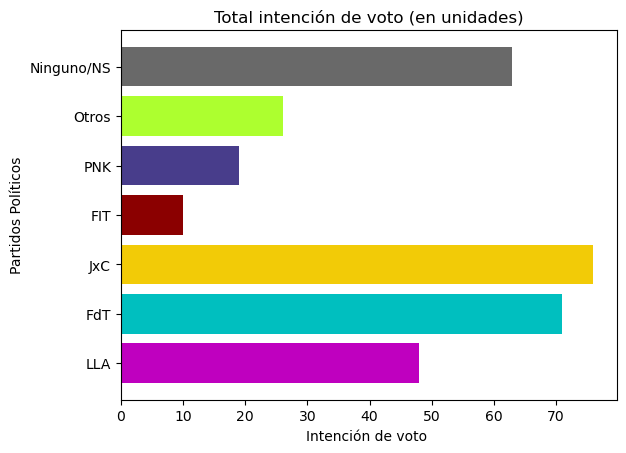

In [284]:
colores_partidos =["#BF00BF","#00BFBF","#F2CB07","#8B0000","#483D8B","#ADFF2F","#696969"]
partidos= ["LLA","FdT","JxC","FIT","PNK", "Otros","Ninguno/NS"]
valores= [LLA_total,FdT_total,JxC_total,FIT_total,PNK_total,Otros_total,Ninguno_NoSabe_total]
plt.barh(partidos, valores, color= colores_partidos)
plt.xlabel("Intención de voto ")
plt.ylabel("Partidos Políticos")
plt.title("Total intención de voto (en unidades)")
plt.show()

In [285]:
#Total de personas que intencionan votar a La Libertad Avanza por rango de edad
filtro1_LLA = (df["INT DE VOTO X ESPACIO"] == "LIBERTARIOS") & (df["EDAD"] == "16 a 25")
LLA_r1 = df[filtro1_LLA].shape[0] 
filtro2_LLA= (df["INT DE VOTO X ESPACIO"] == "LIBERTARIOS") & (df["EDAD"] == "26 a 35")
LLA_r2 = df[filtro2_LLA].shape[0] 
filtro3_LLA= (df["INT DE VOTO X ESPACIO"] == "LIBERTARIOS") & (df["EDAD"] == "36 a 45")
LLA_r3 = df[filtro3_LLA].shape[0]
filtro4_LLA= (df["INT DE VOTO X ESPACIO"] == "LIBERTARIOS") & (df["EDAD"] == "46 a 55")
LLA_r4 = df[filtro4_LLA].shape[0]
filtro5_LLA= (df["INT DE VOTO X ESPACIO"] == "LIBERTARIOS") & (df["EDAD"] == "56 y mas")
LLA_r5 = df[filtro5_LLA].shape[0]

print(f"{LLA_r1} personas de entre 16 y 25 años planean votar a La Libertad Avanza \n"
       f"{LLA_r2} personas de entre 26 a 35 años planean votar a La Libertad Avanza \n"
       f"{LLA_r3} personas de entre 36 a 45 años planean votar a La Libertad Avanza \n"
       f"{LLA_r4} personas de entre 46 a 55 años planean votar a La Libertad Avanza \n"
       f"{LLA_r5} personas de entre 56 y más años planean votar a La Libertad Avanza \n")


6 personas de entre 16 y 25 años planean votar a La Libertad Avanza 
7 personas de entre 26 a 35 años planean votar a La Libertad Avanza 
13 personas de entre 36 a 45 años planean votar a La Libertad Avanza 
10 personas de entre 46 a 55 años planean votar a La Libertad Avanza 
12 personas de entre 56 y más años planean votar a La Libertad Avanza 



In [286]:
#Intención de voto de La Libertad Avanza por género

filtroV_LLA = (df["INT DE VOTO X ESPACIO"] == "LIBERTARIOS") & (df["GENERO"] == "Masculino")
LLA_varones = df[filtroV_LLA].shape[0] 

filtroM_LLA = (df["INT DE VOTO X ESPACIO"] == "LIBERTARIOS") & (df["GENERO"] == "Femenino")
LLA_mujeres = df[filtroM_LLA].shape[0] 

filtroO_LLA = (df["INT DE VOTO X ESPACIO"] == "LIBERTARIOS") & (df["GENERO"] == "Otro")
LLA_otros = df[filtroO_LLA].shape[0] 

print (f"{LLA_varones} hombres piensan votar a La Libertad Avanza \n"
       f"{LLA_mujeres} mujeres piensan votar a La Libertad Avanza \n"
       f"{LLA_otros} otros piensan votar a La Libertad Avanza \n")


39 hombres piensan votar a La Libertad Avanza 
8 mujeres piensan votar a La Libertad Avanza 
1 otros piensan votar a La Libertad Avanza 



In [287]:
#Total de personas que intencionan votar al Frente de Todos por rango de edad
filtro1_FdT = (df["INT DE VOTO X ESPACIO"] == "FdT") & (df["EDAD"] == "16 a 25")
FdT_r1 = df[filtro1_FdT].shape[0] 

filtro2_FdT= (df["INT DE VOTO X ESPACIO"] == "FdT") & (df["EDAD"] == "26 a 35")
FdT_r2 = df[filtro2_FdT].shape[0] 

filtro3_FdT= (df["INT DE VOTO X ESPACIO"] == "FdT") & (df["EDAD"] == "36 a 45")
FdT_r3 = df[filtro3_FdT].shape[0]

filtro4_FdT= (df["INT DE VOTO X ESPACIO"] == "FdT") & (df["EDAD"] == "46 a 55")
FdT_r4 = df[filtro4_FdT].shape[0]

filtro5_FdT= (df["INT DE VOTO X ESPACIO"] == "FdT") & (df["EDAD"] == "56 y mas")
FdT_r5 = df[filtro5_FdT].shape[0]

print(f"{FdT_r1} personas de entre 16 y 25 años planean votar al Frente de Todos \n"
       f"{FdT_r2} personas de entre 26 a 35 años planean votar al Frente de Todos \n"
       f"{FdT_r3} personas de entre 36 a 45 años planean votar al Frente de Todos \n"
       f"{FdT_r4} personas de entre 46 a 55 años planean votar al Frente de Todos \n"
       f"{FdT_r5} personas de entre 56 y más años planean votar al Frente de Todos \n")

4 personas de entre 16 y 25 años planean votar al Frente de Todos 
12 personas de entre 26 a 35 años planean votar al Frente de Todos 
23 personas de entre 36 a 45 años planean votar al Frente de Todos 
9 personas de entre 46 a 55 años planean votar al Frente de Todos 
23 personas de entre 56 y más años planean votar al Frente de Todos 



In [288]:
#Intención de voto del Frente de Todos por género
filtroV_FdT = (df["INT DE VOTO X ESPACIO"] == "FdT") & (df["GENERO"] == "Masculino")
FdT_varones = df[filtroV_FdT].shape[0] 

filtroM_FdT = (df["INT DE VOTO X ESPACIO"] == "FdT") & (df["GENERO"] == "Femenino")
FdT_mujeres = df[filtroM_FdT].shape[0] 

filtroO_FdT = (df["INT DE VOTO X ESPACIO"] == "FdT") & (df["GENERO"] == "Otro")
FdT_otros = df[filtroO_FdT].shape[0] 

print (f"{FdT_varones} hombres piensan votar al Frente de Todos \n"
       f"{FdT_mujeres} mujeres piensan votar al Frente de Todos \n"
       f"{FdT_otros} otros piensan votar al Frente de Todos \n")


41 hombres piensan votar al Frente de Todos 
30 mujeres piensan votar al Frente de Todos 
0 otros piensan votar al Frente de Todos 



In [289]:
#Total de personas que intencionan votar a Juntos por el Cambio por rango de edad
filtro1_JxC = (df["INT DE VOTO X ESPACIO"] == "JxC") & (df["EDAD"] == "16 a 25")
JxC_r1 = df[filtro1_JxC].shape[0] 

filtro2_JxC = (df["INT DE VOTO X ESPACIO"] == "JxC") & (df["EDAD"] == "26 a 35")
JxC_r2 = df[filtro2_JxC].shape[0] 

filtro3_JxC = (df["INT DE VOTO X ESPACIO"] == "JxC") & (df["EDAD"] == "36 a 45")
JxC_r3 = df[filtro3_JxC].shape[0]

filtro4_JxC= (df["INT DE VOTO X ESPACIO"] == "JxC") & (df["EDAD"] == "46 a 55")
JxC_r4 = df[filtro4_JxC].shape[0]

filtro5_JxC= (df["INT DE VOTO X ESPACIO"] == "JxC") & (df["EDAD"] == "56 y mas")
JxC_r5 = df[filtro5_JxC].shape[0]

print(f"{JxC_r1} personas de entre 16 y 25 años planean votar a Juntos por el Cambio \n"
       f"{JxC_r2} personas de entre 26 a 35 años planean votara Juntos por el Cambio \n"
       f"{JxC_r3} personas de entre 36 a 45 años planean votar a Juntos por el Cambio \n"
       f"{JxC_r4} personas de entre 46 a 55 años planean votar a Juntos por el Cambio \n"
       f"{JxC_r5} personas de entre 56 y más años planean votar a Juntos por el Cambio \n")

5 personas de entre 16 y 25 años planean votar a Juntos por el Cambio 
8 personas de entre 26 a 35 años planean votara Juntos por el Cambio 
20 personas de entre 36 a 45 años planean votar a Juntos por el Cambio 
18 personas de entre 46 a 55 años planean votar a Juntos por el Cambio 
25 personas de entre 56 y más años planean votar a Juntos por el Cambio 



In [290]:
#Intención de voto de Juntos por el Cambio por género
filtroV_JxC = (df["INT DE VOTO X ESPACIO"] == "JxC") & (df["GENERO"] == "Masculino")
JxC_varones = df[filtroV_JxC].shape[0] 

filtroM_JxC = (df["INT DE VOTO X ESPACIO"] == "JxC") & (df["GENERO"] == "Femenino")
JxC_mujeres = df[filtroM_JxC].shape[0] 

filtroO_JxC = (df["INT DE VOTO X ESPACIO"] == "JxC") & (df["GENERO"] == "Otro")
JxC_otros = df[filtroO_JxC].shape[0] 

print (f"{JxC_varones} hombres piensan votar a Juntos por el Cambio \n"
       f"{JxC_mujeres} mujeres piensan votar a Juntos por el Cambio \n"
       f"{JxC_otros} otros piensan votar a Juntos por el Cambio \n")

39 hombres piensan votar a Juntos por el Cambio 
37 mujeres piensan votar a Juntos por el Cambio 
0 otros piensan votar a Juntos por el Cambio 



In [291]:
#Total de personas que intencionan votar al Frente de Izquierda por rango de edad
filtro1_FIT = (df["INT DE VOTO X ESPACIO"] == "FIT") & (df["EDAD"] == "16 a 25")
FIT_r1 = df[filtro1_FIT].shape[0] 

filtro2_FIT = (df["INT DE VOTO X ESPACIO"] == "FIT") & (df["EDAD"] == "26 a 35")
FIT_r2 = df[filtro2_FIT].shape[0] 

filtro3_FIT = (df["INT DE VOTO X ESPACIO"] == "FIT") & (df["EDAD"] == "36 a 45")
FIT_r3 = df[filtro3_FIT].shape[0]

filtro4_FIT= (df["INT DE VOTO X ESPACIO"] == "FIT") & (df["EDAD"] == "46 a 55")
FIT_r4 = df[filtro4_FIT].shape[0]

filtro5_FIT= (df["INT DE VOTO X ESPACIO"] == "FIT") & (df["EDAD"] == "56 y mas")
FIT_r5 = df[filtro5_FIT].shape[0]

print(f"{FIT_r1} personas de entre 16 y 25 años planean votar al Frente de Izquierda \n"
       f"{FIT_r2} personas de entre 26 a 35 años planean votar al Frente de Izquierda \n"
       f"{FIT_r3} personas de entre 36 a 45 años planean votar al Frente de Izquierda \n"
       f"{FIT_r4} personas de entre 46 a 55 años planean votar al Frente de Izquierda \n"
       f"{FIT_r5} personas de entre 56 y más años planean votar al Frente de Izquierda \n")




1 personas de entre 16 y 25 años planean votar al Frente de Izquierda 
3 personas de entre 26 a 35 años planean votar al Frente de Izquierda 
4 personas de entre 36 a 45 años planean votar al Frente de Izquierda 
1 personas de entre 46 a 55 años planean votar al Frente de Izquierda 
1 personas de entre 56 y más años planean votar al Frente de Izquierda 



In [292]:
#Intención de voto del Frente de Izquierda por género
filtroV_FIT = (df["INT DE VOTO X ESPACIO"] == "FIT") & (df["GENERO"] == "Masculino")
FIT_varones = df[filtroV_FIT].shape[0] 

filtroM_FIT = (df["INT DE VOTO X ESPACIO"] == "FIT") & (df["GENERO"] == "Femenino")
FIT_mujeres = df[filtroM_FIT].shape[0] 

filtroO_FIT = (df["INT DE VOTO X ESPACIO"] == "FIT") & (df["GENERO"] == "Otro")
FIT_otros = df[filtroO_FIT].shape[0] 

print (f"{FIT_varones} hombres piensan votar al Frente de Izquierda \n"
       f"{FIT_mujeres} mujeres piensan votar al Frente de Izquierda \n"
       f"{FIT_otros} otros piensan votar al Frente de Izquierda \n")

4 hombres piensan votar al Frente de Izquierda 
4 mujeres piensan votar al Frente de Izquierda 
2 otros piensan votar al Frente de Izquierda 



In [293]:
#Total de personas que intencionan votar al Peronismo No Kircherista por rango de edad
filtro1_PNK = (df["INT DE VOTO X ESPACIO"] == "PNK") & (df["EDAD"] == "16 a 25")
PNK_r1 = df[filtro1_PNK].shape[0] 

filtro2_PNK = (df["INT DE VOTO X ESPACIO"] == "PNK") & (df["EDAD"] == "26 a 35")
PNK_r2 = df[filtro2_PNK].shape[0] 

filtro3_PNK = (df["INT DE VOTO X ESPACIO"] == "PNK") & (df["EDAD"] == "36 a 45")
PNK_r3 = df[filtro3_PNK].shape[0]

filtro4_PNK= (df["INT DE VOTO X ESPACIO"] == "PNK") & (df["EDAD"] == "46 a 55")
PNK_r4 = df[filtro4_PNK].shape[0]

filtro5_PNK= (df["INT DE VOTO X ESPACIO"] == "PNK") & (df["EDAD"] == "56 y mas")
PNK_r5 = df[filtro5_PNK].shape[0]

print(f"{PNK_r1} personas de entre 16 y 25 años planean votar al Peronismo No Kircherista \n"
       f"{PNK_r2} personas de entre 26 a 35 años planean votar al Peronismo No Kircherista \n"
       f"{PNK_r3} personas de entre 36 a 45 años planean votar al Peronismo No Kircherista \n"
       f"{PNK_r4} personas de entre 46 a 55 años planean votar al Peronismo No Kircherista \n"
       f"{PNK_r5} personas de entre 56 y más años planean votar al Peronismo No Kircherista \n")

0 personas de entre 16 y 25 años planean votar al Peronismo No Kircherista 
4 personas de entre 26 a 35 años planean votar al Peronismo No Kircherista 
7 personas de entre 36 a 45 años planean votar al Peronismo No Kircherista 
2 personas de entre 46 a 55 años planean votar al Peronismo No Kircherista 
6 personas de entre 56 y más años planean votar al Peronismo No Kircherista 



In [294]:
#Intención de voto del Peronismo No Kirchnerista por género
filtroV_PNK = (df["INT DE VOTO X ESPACIO"] == "PNK") & (df["GENERO"] == "Masculino")
PNK_varones = df[filtroV_PNK].shape[0] 

filtroM_PNK = (df["INT DE VOTO X ESPACIO"] == "PNK") & (df["GENERO"] == "Femenino")
PNK_mujeres = df[filtroM_PNK].shape[0] 

filtroO_PNK = (df["INT DE VOTO X ESPACIO"] == "PNK") & (df["GENERO"] == "Otro")
PNK_otros = df[filtroO_PNK].shape[0] 

print (f"{PNK_varones} hombres piensan votar al Peronismo No Kirchnerista \n"
       f"{PNK_mujeres} mujeres piensan votar al Peronismo No Kirchnerista \n"
       f"{PNK_otros} otros piensan votar al Peronismo No Kirchnerista \n")


10 hombres piensan votar al Peronismo No Kirchnerista 
9 mujeres piensan votar al Peronismo No Kirchnerista 
0 otros piensan votar al Peronismo No Kirchnerista 



In [295]:
#Total de personas que intencionan votar a Otros por rango de edad
filtro1_Otros = (df["INT DE VOTO X ESPACIO"] == "OTROS") & (df["EDAD"] == "16 a 25")
Otros_r1 = df[filtro1_Otros].shape[0] 

filtro2_Otros = (df["INT DE VOTO X ESPACIO"] == "OTROS") & (df["EDAD"] == "26 a 35")
Otros_r2 = df[filtro2_Otros].shape[0] 

filtro3_Otros = (df["INT DE VOTO X ESPACIO"] == "OTROS") & (df["EDAD"] == "36 a 45")
Otros_r3 = df[filtro3_Otros].shape[0]

filtro4_Otros= (df["INT DE VOTO X ESPACIO"] == "OTROS") & (df["EDAD"] == "46 a 55")
Otros_r4 = df[filtro4_Otros].shape[0]

filtro5_Otros= (df["INT DE VOTO X ESPACIO"] == "OTROS") & (df["EDAD"] == "56 y mas")
Otros_r5 = df[filtro5_Otros].shape[0]

print(f"{Otros_r1} personas de entre 16 y 25 años planean votar a Otros \n"
       f"{Otros_r2} personas de entre 26 a 35 años planean votar a Otros \n"
       f"{Otros_r3} personas de entre 36 a 45 años planean votar a Otros \n"
       f"{Otros_r4} personas de entre 46 a 55 años planean votar a Otros \n"
       f"{Otros_r5} personas de entre 56 y más años planean votar a Otros \n")

0 personas de entre 16 y 25 años planean votar a Otros 
4 personas de entre 26 a 35 años planean votar a Otros 
6 personas de entre 36 a 45 años planean votar a Otros 
12 personas de entre 46 a 55 años planean votar a Otros 
4 personas de entre 56 y más años planean votar a Otros 



In [296]:
#Intención de voto de Otros por género
filtroV_Otros = (df["INT DE VOTO X ESPACIO"] == "OTROS") & (df["GENERO"] == "Masculino")
Otros_varones = df[filtroV_Otros].shape[0] 

filtroM_Otros = (df["INT DE VOTO X ESPACIO"] == "OTROS") & (df["GENERO"] == "Femenino")
Otros_mujeres = df[filtroM_Otros].shape[0] 

filtroO_Otros = (df["INT DE VOTO X ESPACIO"] == "OTROS") & (df["GENERO"] == "Otro")
Otros_otros = df[filtroO_Otros].shape[0] 

print(f"{Otros_varones} hombres piensan votar a Otros \n"
       f"{Otros_mujeres} mujeres piensan votar a Otros \n"
       f"{Otros_otros} otros piensan votar a Otros \n")

11 hombres piensan votar a Otros 
14 mujeres piensan votar a Otros 
1 otros piensan votar a Otros 



In [297]:
#Total de personas que intencionan no votar a ninguno de los partidos polítiicos mencionados o aún saben a cuál votarán
filtro1_Ninguno_NoSabe = (df["INT DE VOTO X ESPACIO"] == "NINGUNO/NOSABE") & (df["EDAD"] == "16 a 25")
Ninguno_NoSabe_r1 = df[filtro1_Ninguno_NoSabe].shape[0] 

filtro2_Ninguno_NoSabe = (df["INT DE VOTO X ESPACIO"] == "NINGUNO/NOSABE") & (df["EDAD"] == "26 a 35")
Ninguno_NoSabe_r2 = df[filtro2_Ninguno_NoSabe].shape[0] 

filtro3_Ninguno_NoSabe = (df["INT DE VOTO X ESPACIO"] == "NINGUNO/NOSABE") & (df["EDAD"] == "36 a 45")
Ninguno_NoSabe_r3 = df[filtro3_Ninguno_NoSabe].shape[0]

filtro4_Ninguno_NoSabe= (df["INT DE VOTO X ESPACIO"] == "NINGUNO/NOSABE") & (df["EDAD"] == "46 a 55")
Ninguno_NoSabe_r4 = df[filtro4_Ninguno_NoSabe].shape[0]

filtro5_Ninguno_NoSabe= (df["INT DE VOTO X ESPACIO"] == "NINGUNO/NOSABE") & (df["EDAD"] == "56 y mas")
Ninguno_NoSabe_r5 = df[filtro5_Ninguno_NoSabe].shape[0]

print(f"{Ninguno_NoSabe_r1} personas de entre 16 y 25 años planean no votar a ninguno de los partidos polítiicos mencionados o aún saben a cuál votarán \n"
       f"{Ninguno_NoSabe_r2} personas de entre 26 a 35 años planean no votar a ninguno de los partidos polítiicos mencionados o aún saben a cuál votarán \n"
       f"{Ninguno_NoSabe_r3} personas de entre 36 a 45 años planean no votar a ninguno de los partidos polítiicos mencionados o aún saben a cuál votarán \n"
       f"{Ninguno_NoSabe_r4} personas de entre 46 a 55 años planean no votar a ninguno de los partidos polítiicos mencionados o aún saben a cuál votarán \n"
       f"{Ninguno_NoSabe_r5} personas de entre 56 y más años planean no votar a ninguno de los partidos polítiicos mencionados o aún saben a cuál votarán \n")


4 personas de entre 16 y 25 años planean no votar a ninguno de los partidos polítiicos mencionados o aún saben a cuál votarán 
11 personas de entre 26 a 35 años planean no votar a ninguno de los partidos polítiicos mencionados o aún saben a cuál votarán 
15 personas de entre 36 a 45 años planean no votar a ninguno de los partidos polítiicos mencionados o aún saben a cuál votarán 
18 personas de entre 46 a 55 años planean no votar a ninguno de los partidos polítiicos mencionados o aún saben a cuál votarán 
15 personas de entre 56 y más años planean no votar a ninguno de los partidos polítiicos mencionados o aún saben a cuál votarán 



In [298]:
#Intención de no votar a ninguno de ellos por género
filtroV_Ninguno_NoSabe = (df["INT DE VOTO X ESPACIO"] == "NINGUNO/NOSABE") & (df["GENERO"] == "Masculino")
Ninguno_NoSabe_varones = df[filtroV_Ninguno_NoSabe].shape[0] 

filtroM_Ninguno_NoSabe = (df["INT DE VOTO X ESPACIO"] == "NINGUNO/NOSABE") & (df["GENERO"] == "Femenino")
Ninguno_NoSabe_mujeres = df[filtroM_Ninguno_NoSabe].shape[0] 

filtroO_Ninguno_NoSabe = (df["INT DE VOTO X ESPACIO"] == "NINGUNO/NOSABE") & (df["GENERO"] == "Otro")
Ninguno_NoSabe_otros = df[filtroO_Ninguno_NoSabe].shape[0] 

print(f"{Ninguno_NoSabe_varones} hombres piensan no votar a ninguno de ellos \n"
       f"{Ninguno_NoSabe_mujeres} mujeres piensan no votar a ninguno de ellos \n"
       f"{Ninguno_NoSabe_otros} otros piensan no votar a ninguno de ellos \n")

24 hombres piensan no votar a ninguno de ellos 
37 mujeres piensan no votar a ninguno de ellos 
2 otros piensan no votar a ninguno de ellos 



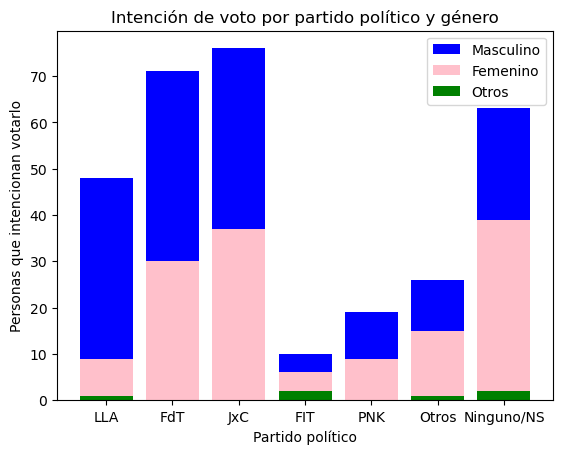

In [299]:
#Gráfico de barras
data= pd.DataFrame({"Masculino": [LLA_varones, FdT_varones,JxC_varones,FIT_varones,PNK_varones,Otros_varones, Ninguno_NoSabe_varones],
                     "Femenino" : [LLA_mujeres,FdT_mujeres,JxC_mujeres,FIT_mujeres,PNK_mujeres,Otros_mujeres, Ninguno_NoSabe_mujeres],
                     "Otros": [LLA_otros,FdT_otros,JxC_otros,FIT_otros, PNK_otros,Otros_otros, Ninguno_NoSabe_otros]},
                     index= ("LLA","FdT","JxC","FIT","PNK", "Otros","Ninguno/NS"))
total = data.sum(axis=1)
plt.bar(data.index, data.Masculino + data.Femenino + data.Otros, label= "Masculino", color="blue")
plt.bar(data.index, data.Femenino + data.Otros, label= "Femenino", color="pink")
plt.bar(data.index, data.Otros, label= "Otros", color= "green")
plt.legend(loc='best')
plt.title("Intención de voto por partido político y género")
plt.xlabel ("Partido político")
plt.ylabel ("Personas que intencionan votarlo")
plt.show()


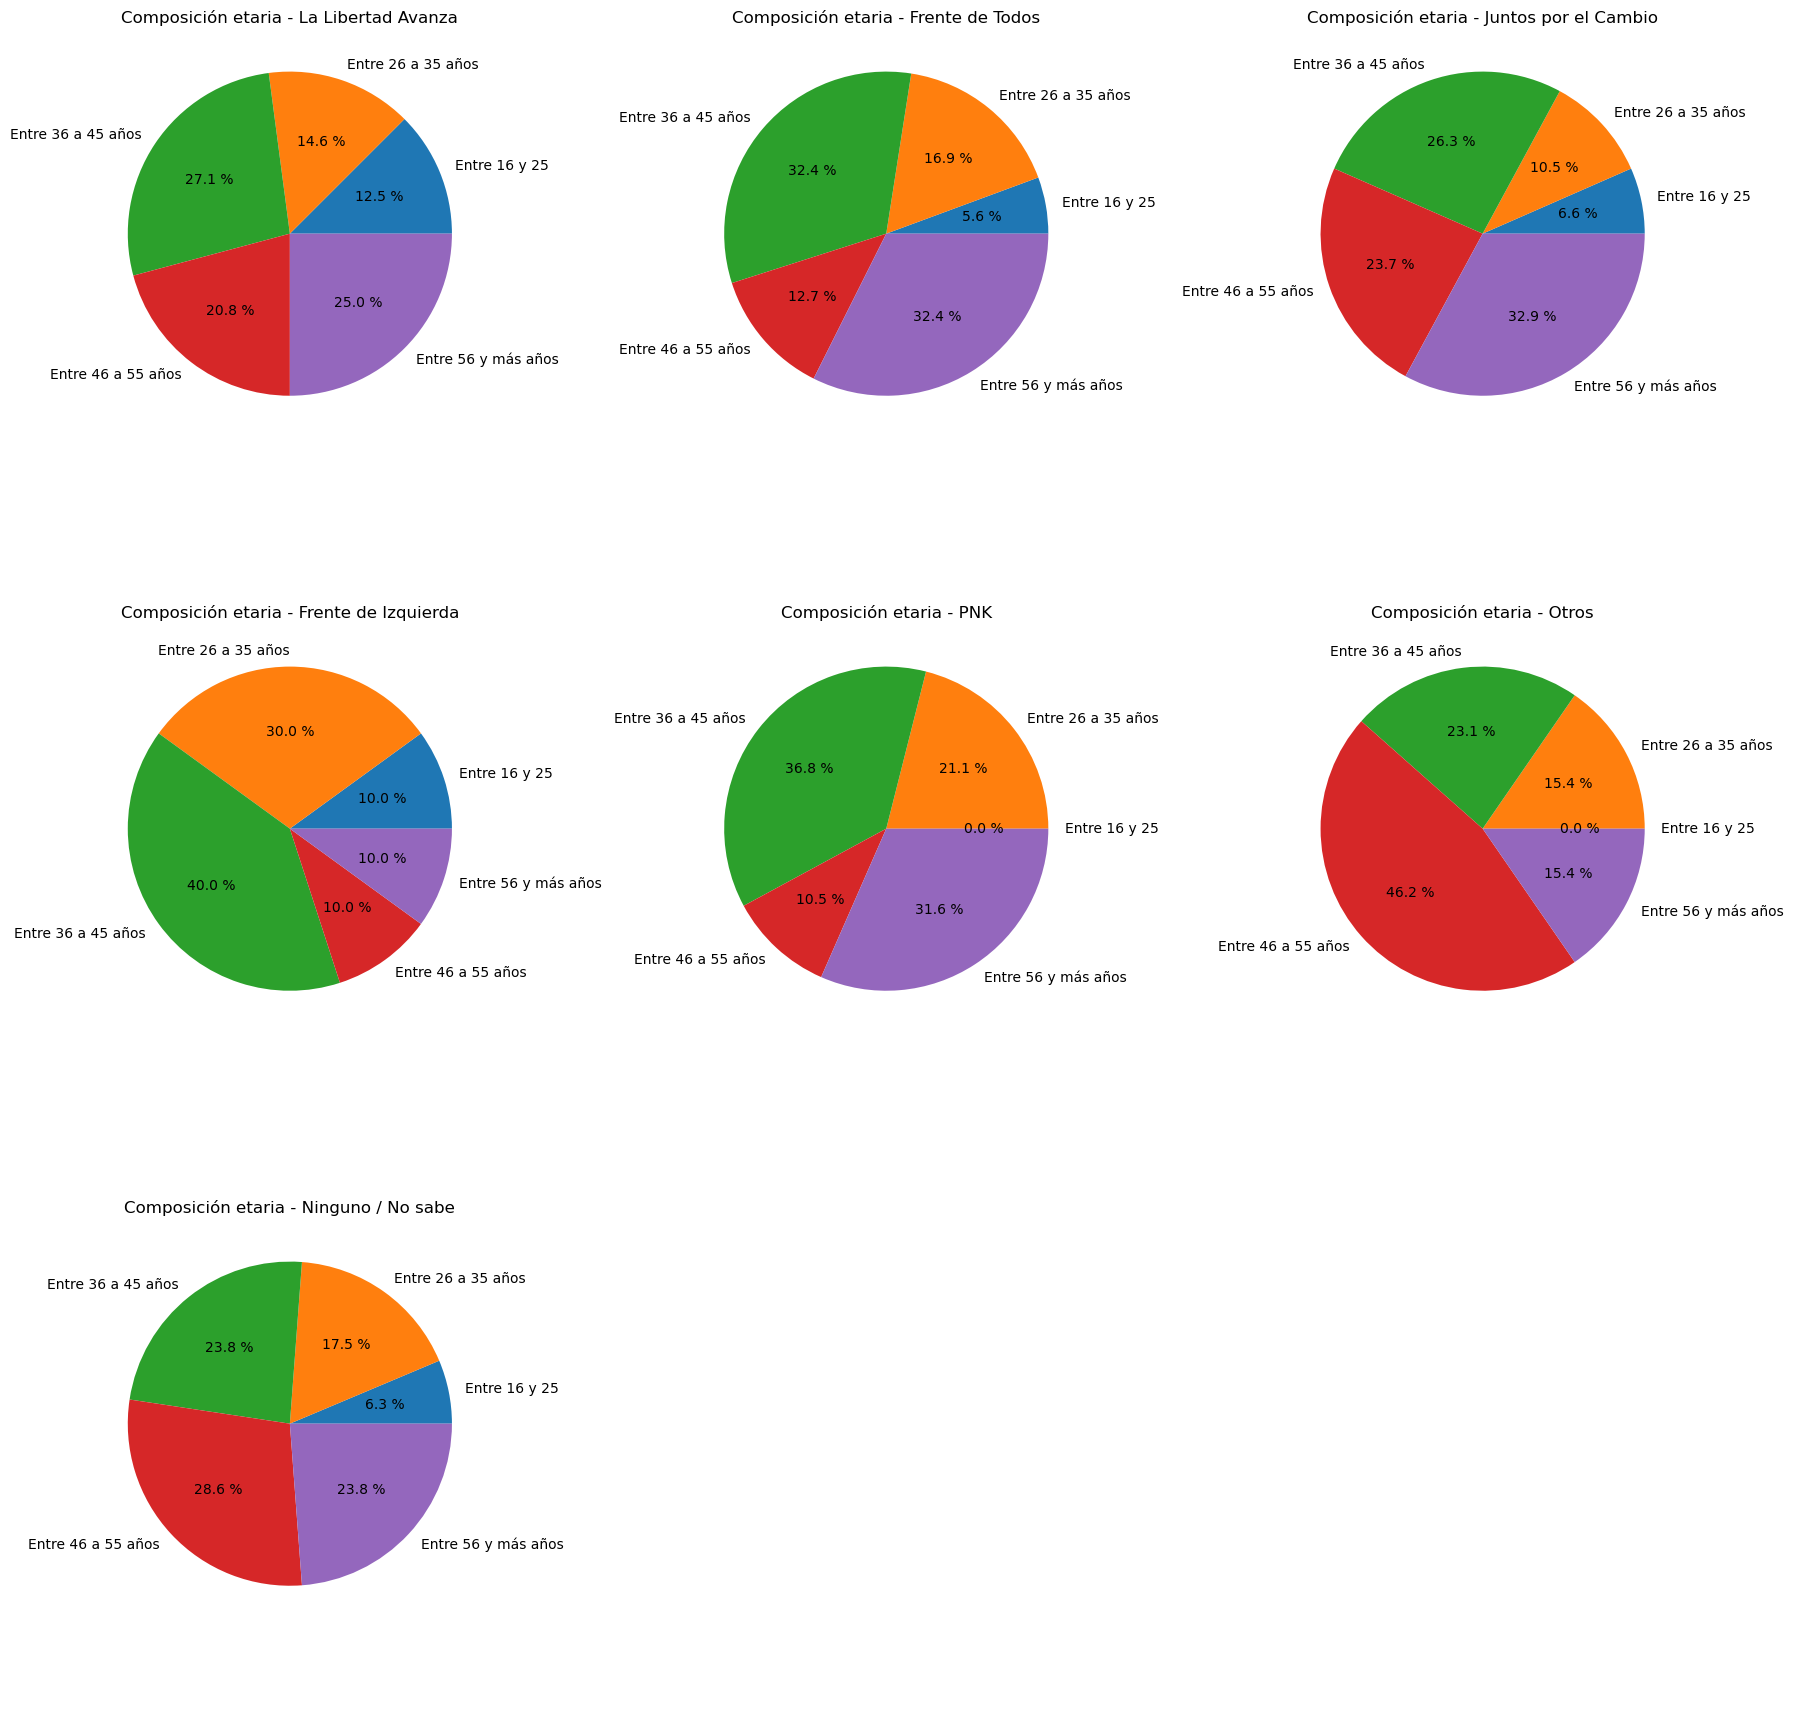

In [300]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # grilla 3x3
axes = axes.flatten()  # para indexar fácilmente los subplots

categorias = ["Entre 16 y 25", "Entre 26 a 35 años", "Entre 36 a 45 años", "Entre 46 a 55 años", "Entre 56 y más años"]

# --- 1) La Libertad Avanza ---
votantesLLA = [LLA_r1, LLA_r2, LLA_r3, LLA_r4, LLA_r5]
axes[0].pie(votantesLLA, labels=categorias, autopct="%0.1f %%")
axes[0].set_title("Composición etaria - La Libertad Avanza")

# --- 2) Frente de Todos ---
votantesFdT = [FdT_r1, FdT_r2, FdT_r3, FdT_r4, FdT_r5]
axes[1].pie(votantesFdT, labels=categorias, autopct="%0.1f %%")
axes[1].set_title("Composición etaria - Frente de Todos")

# --- 3) Juntos por el Cambio ---
votantesJxC = [JxC_r1, JxC_r2, JxC_r3, JxC_r4, JxC_r5]
axes[2].pie(votantesJxC, labels=categorias, autopct="%0.1f %%")
axes[2].set_title("Composición etaria - Juntos por el Cambio")

# --- 4) Frente de Izquierda ---
votantesFIT = [FIT_r1, FIT_r2, FIT_r3, FIT_r4, FIT_r5]
axes[3].pie(votantesFIT, labels=categorias, autopct="%0.1f %%")
axes[3].set_title("Composición etaria - Frente de Izquierda")

# --- 5) Peronismo No Kirchnerista ---
votantesPNK = [PNK_r1, PNK_r2, PNK_r3, PNK_r4, PNK_r5]
axes[4].pie(votantesPNK, labels=categorias, autopct="%0.1f %%")
axes[4].set_title("Composición etaria - PNK")

# --- 6) Otros ---
votantesOtros = [Otros_r1, Otros_r2, Otros_r3, Otros_r4, Otros_r5]
axes[5].pie(votantesOtros, labels=categorias, autopct="%0.1f %%")
axes[5].set_title("Composición etaria - Otros")

# --- 7) Ninguno / No sabe ---
votantesNinguno_NoSabe = [Ninguno_NoSabe_r1, Ninguno_NoSabe_r2, Ninguno_NoSabe_r3, Ninguno_NoSabe_r4, Ninguno_NoSabe_r5]
axes[6].pie(votantesNinguno_NoSabe, labels=categorias, autopct="%0.1f %%")
axes[6].set_title("Composición etaria - Ninguno / No sabe")

# --- 8 y 9 vacíos (por si querés agregar más adelante o dejarlos en blanco) ---
axes[7].axis("off")
axes[8].axis("off")

plt.tight_layout()
plt.show()


# Caracterización del voto por partido

## 📊 La Libertad Avanza
- **Total**: 49 personas.
- **Género**: 39 hombres, 8 mujeres, 1 otros. → Electorado fuertemente masculino.
- **Edad más fuerte**: 36 a 45 años (13 personas).
- **Edad más débil**: 16 a 25 años (6 personas).
- **Síntesis**: El voto a LLA se concentra en **hombres de mediana edad**, con baja penetración en los más jóvenes.

---

## 📊 Frente de Todos
- **Total**: 71 personas.
- **Género**: 41 hombres, 30 mujeres. → Electorado relativamente balanceado.
- **Edad más fuerte**: 36 a 45 años (23) y 56+ (23).
- **Edad más débil**: 16 a 25 años (4 personas).
- **Síntesis**: El FdT muestra mayor apoyo en **adultos y mayores**, con menor atractivo en los más jóvenes.

---

## 📊 Juntos por el Cambio
- **Total**: 76 personas.
- **Género**: 39 hombres, 37 mujeres. → Equilibrio casi perfecto por género.
- **Edad más fuerte**: 56+ (25 personas).
- **Edad más débil**: 16 a 25 años (5 personas).
- **Síntesis**: JxC es **intergeneracional pero con peso en los mayores**, y se caracteriza por un electorado balanceado entre hombres y mujeres.

---

## 📊 Frente de Izquierda
- **Total**: 10 personas.
- **Género**: 4 hombres, 4 mujeres, 2 otros. → Distribución muy equitativa.
- **Edad más fuerte**: 26 a 35 años (3) y 36 a 45 años (4).
- **Edad más débil**: 16 a 25 años (1) y 56+ (1).
- **Síntesis**: Electorado reducido pero diverso, con **peso en adultos jóvenes**, presencia equitativa por género e inclusión en “otros”.

---

## 📊 Peronismo No Kirchnerista
- **Total**: 19 personas.
- **Género**: 10 hombres, 9 mujeres. → Balanceado.
- **Edad más fuerte**: 56+ (6 personas).
- **Edad más débil**: 16 a 25 años (0 personas).
- **Síntesis**: Espacio con **perfil adulto-mayor**, casi sin penetración en jóvenes.

---

## 📊 Otros
- **Total**: 26 personas.
- **Género**: 11 hombres, 14 mujeres, 1 otros. → Predominio femenino.
- **Edad más fuerte**: 46 a 55 años (12 personas).
- **Edad más débil**: 16 a 25 años (0 personas).
- **Síntesis**: Agrupación heterogénea con apoyo en **adultos medios**, mayor proporción femenina.

---

## 📊 No votan / indecisos
- **Total**: 59 personas.
- **Género**: 24 hombres, 37 mujeres, 2 otros. → Predominio femenino.
- **Edad más fuerte**: 46 a 55 años (18) y 56+ (15).
- **Edad más débil**: 16 a 25 años (4).
- **Síntesis**: Segmento de **indecisos o abstencionistas**, concentrado en **mujeres y adultos mayores**.

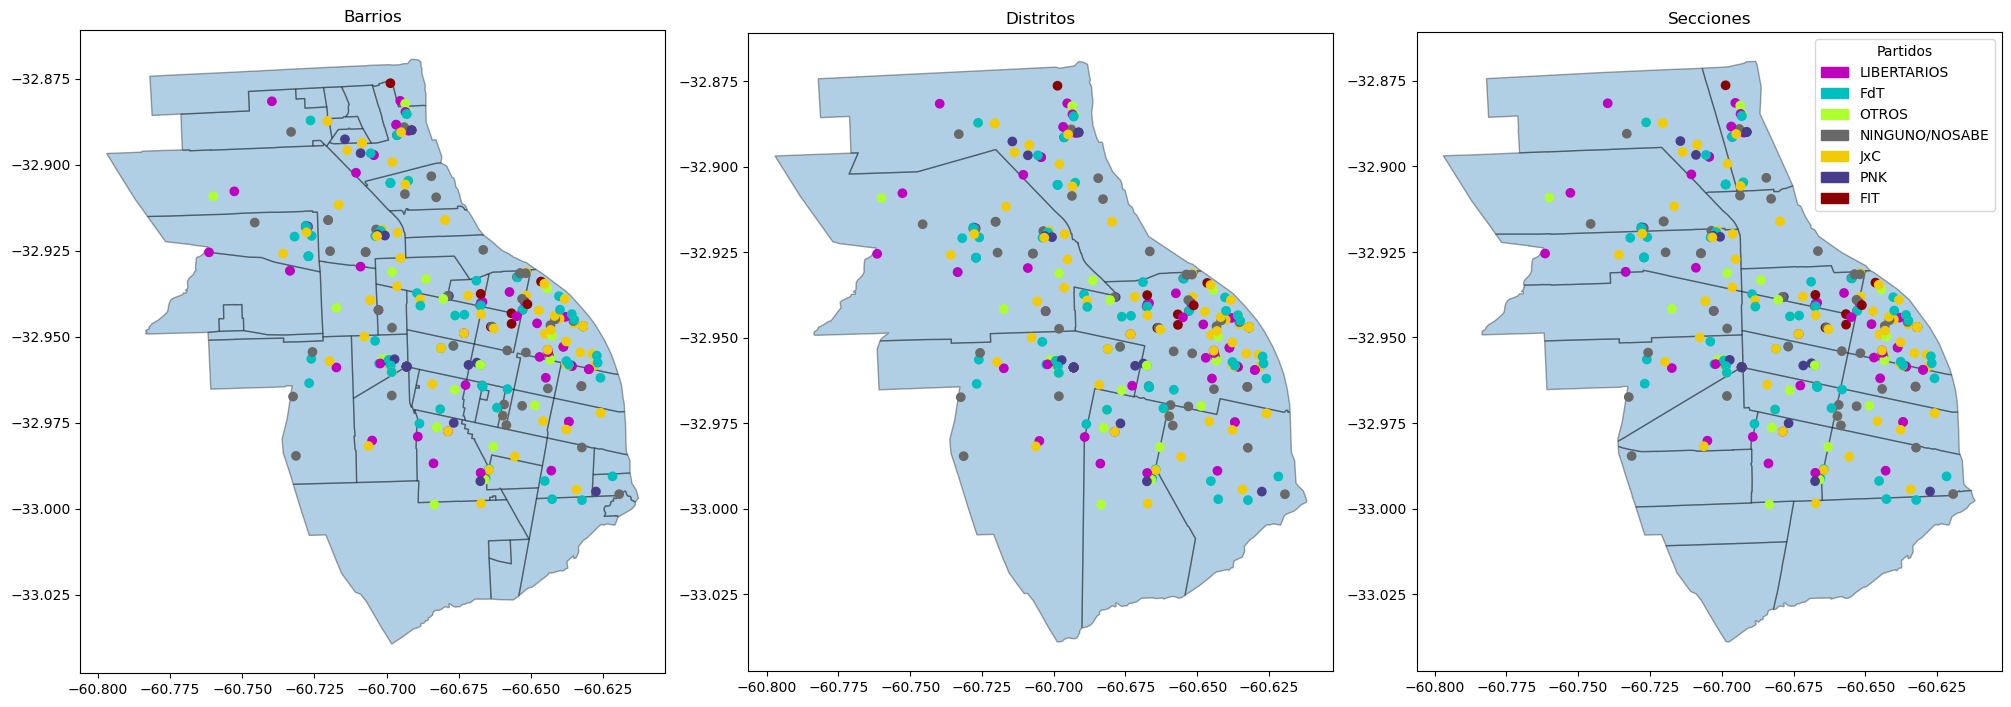

In [301]:
colores_partidos = {
    'LIBERTARIOS': '#BF00BF',
    'FdT': '#00BFBF',
    'OTROS': '#ADFF2F',
    'NINGUNO/NOSABE': '#696969',
    'JxC': '#F2CB07',
    'PNK': '#483D8B',
    'FIT': '#8B0000',
}
fig, axes = plt.subplots(1, 3, figsize=(20, 10), constrained_layout=True)
base = barrios.plot(figsize=(20, 20), alpha=0.35, edgecolor='k', ax=axes[0])
gdf.plot(ax=base, color=gdf['color'])
axes[0].set_title('Barrios')
base = distritos.plot(figsize=(20, 20), alpha=0.35, edgecolor='k', ax=axes[1])
gdf.plot(ax=base, color=gdf['color'])
axes[1].set_title('Distritos')
base = secciones.plot(figsize=(20, 20), alpha=0.35, edgecolor='k', ax=axes[2])
gdf.plot(ax=base, legend=True, color=gdf['color'])
axes[2].set_title('Secciones')
leyenda = [mpatches.Patch(color=color, label=partido) for partido, color in colores_partidos.items()]

plt.legend(handles=leyenda, title='Partidos', loc='upper right', fontsize=10)
plt.show()

### Análisis espacial de la distribución de encuestados

A partir de la representación geográfica por barrios, distritos y secciones, se observa que la *mayor densidad de encuestados* se concentra en **el barrio Centro de Rosario**, arrastrando esta condición al distrito Centro, ubicado en torno a las coordenadas aproximadas (-60.650, -32.936). Este distrito, que corresponde a la zona más poblada y céntrica de la ciudad, reúne la mayor cantidad de puntos en comparación con el resto. En cambio, hacia el oeste y sur de Rosario la distribución es más dispersa y con menor cantidad de encuestados.  

En términos comparativos:  
- El **Centro** aparece como el núcleo de concentración, reflejando tanto su peso demográfico como su rol de centralidad urbana.  
- Los **distritos periféricos** muestran menor densidad de encuestados, lo que puede responder a factores poblacionales y de acceso.  
- Esta distribución espacial permite contextualizar los patrones electorales en función del territorio, mostrando que la zona céntrica concentra no solo población sino también diversidad política.


In [302]:
conteo_votos = (
    union.groupby(['BARRIO', 'INT DE VOTO X ESPACIO'])
    .size()
    .reset_index(name='conteo')
)
mayor_votos_por_barrio = conteo_votos.loc[conteo_votos.groupby('BARRIO')['conteo'].idxmax()]
barrios = barrios.merge(mayor_votos_por_barrio, on='BARRIO', how='left')
barrios['color'] = barrios['INT DE VOTO X ESPACIO'].map(colores_partidos).fillna('black')
conteo_votos_por_barrio = (
    union.groupby('BARRIO')
    .size()
    .reset_index(name='cantidad_votos')
)
barrios = barrios.merge(conteo_votos_por_barrio, on='BARRIO', how='left')

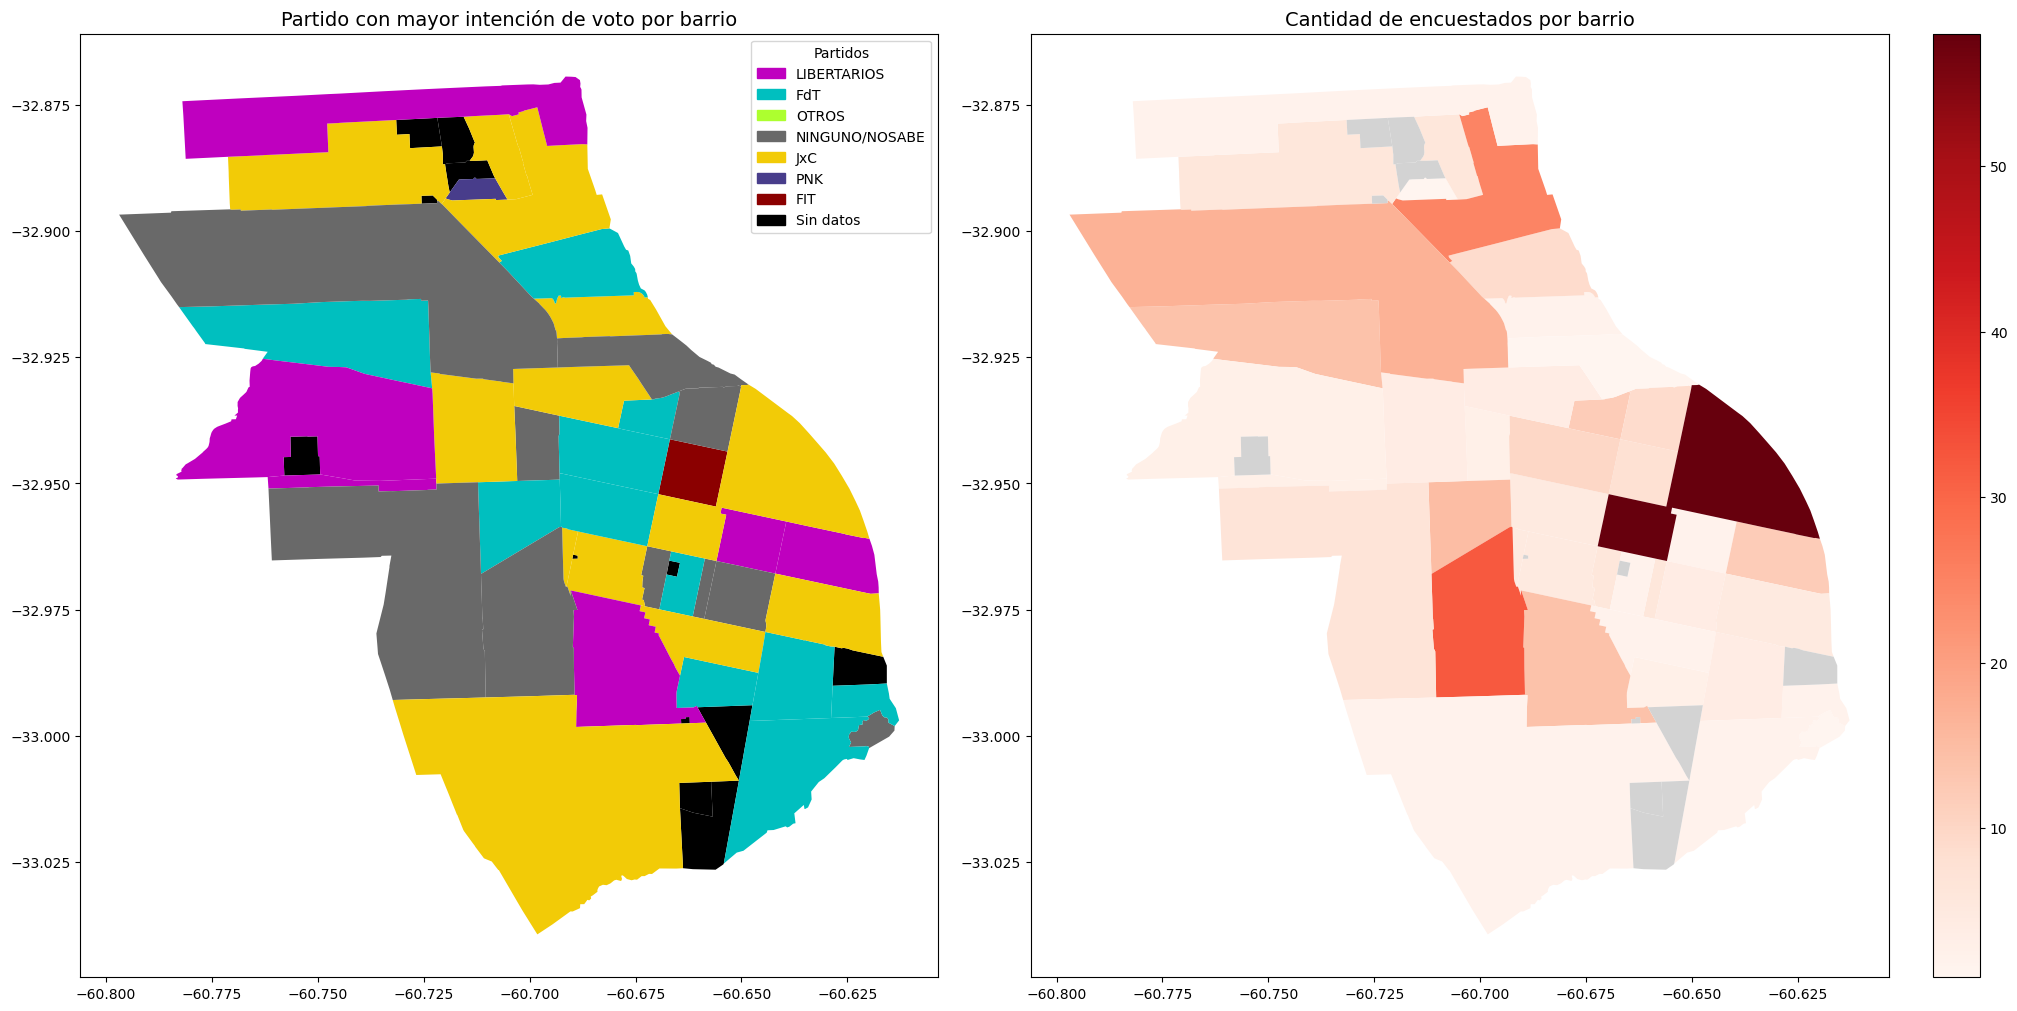

In [303]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)
barrios.plot(color=barrios['color'], ax=axes[0])
axes[0].set_title('Partido con mayor intención de voto por barrio', fontsize=14)
leyenda = [mpatches.Patch(color=color, label=partido) for partido, color in colores_partidos.items()]
leyenda.append(mpatches.Patch(color='black', label='Sin datos'))
axes[0].legend(handles=leyenda, title='Partidos', loc='upper right', fontsize=10)
barrios.plot(
    column='cantidad_votos', 
    cmap='Reds', 
    legend=True, 
    ax=axes[1],
    missing_kwds={
        "color": "lightgrey",
    }
)
axes[1].set_title('Cantidad de encuestados por barrio', fontsize=14)
plt.show()

### Caracterización por barrios

La desagregación de la intención de voto por barrios no permite identificar un patrón claro. Esto se debe a que este nivel de agrupamiento **sobrerrepresenta barrios con muy pocos encuestados** (por ejemplo, 10 casos), en comparación con otros sectores donde la muestra es mucho mayor. No obstante, si se toman como referencia aquellos barrios con mayor volumen de respuestas, se observa que los partidos con mayor presencia relativa son **Juntos por el Cambio (JxC)** y el grupo **Ninguno/No sabe**.


In [304]:
conteo_votos = (
    unionseccion.groupby(['SECCION', 'INT DE VOTO X ESPACIO'])
    .size()
    .reset_index(name='conteo')
)
mayor_votos_por_seccion = conteo_votos.loc[conteo_votos.groupby('SECCION')['conteo'].idxmax()]
secciones = secciones.merge(mayor_votos_por_seccion, on='SECCION', how='left')
secciones['color'] = secciones['INT DE VOTO X ESPACIO'].map(colores_partidos).fillna('black')
conteo_votos_por_secciones = (
    unionseccion.groupby('SECCION')
    .size()
    .reset_index(name='cantidad_votos')
)
secciones = secciones.merge(conteo_votos_por_secciones, on='SECCION', how='left')

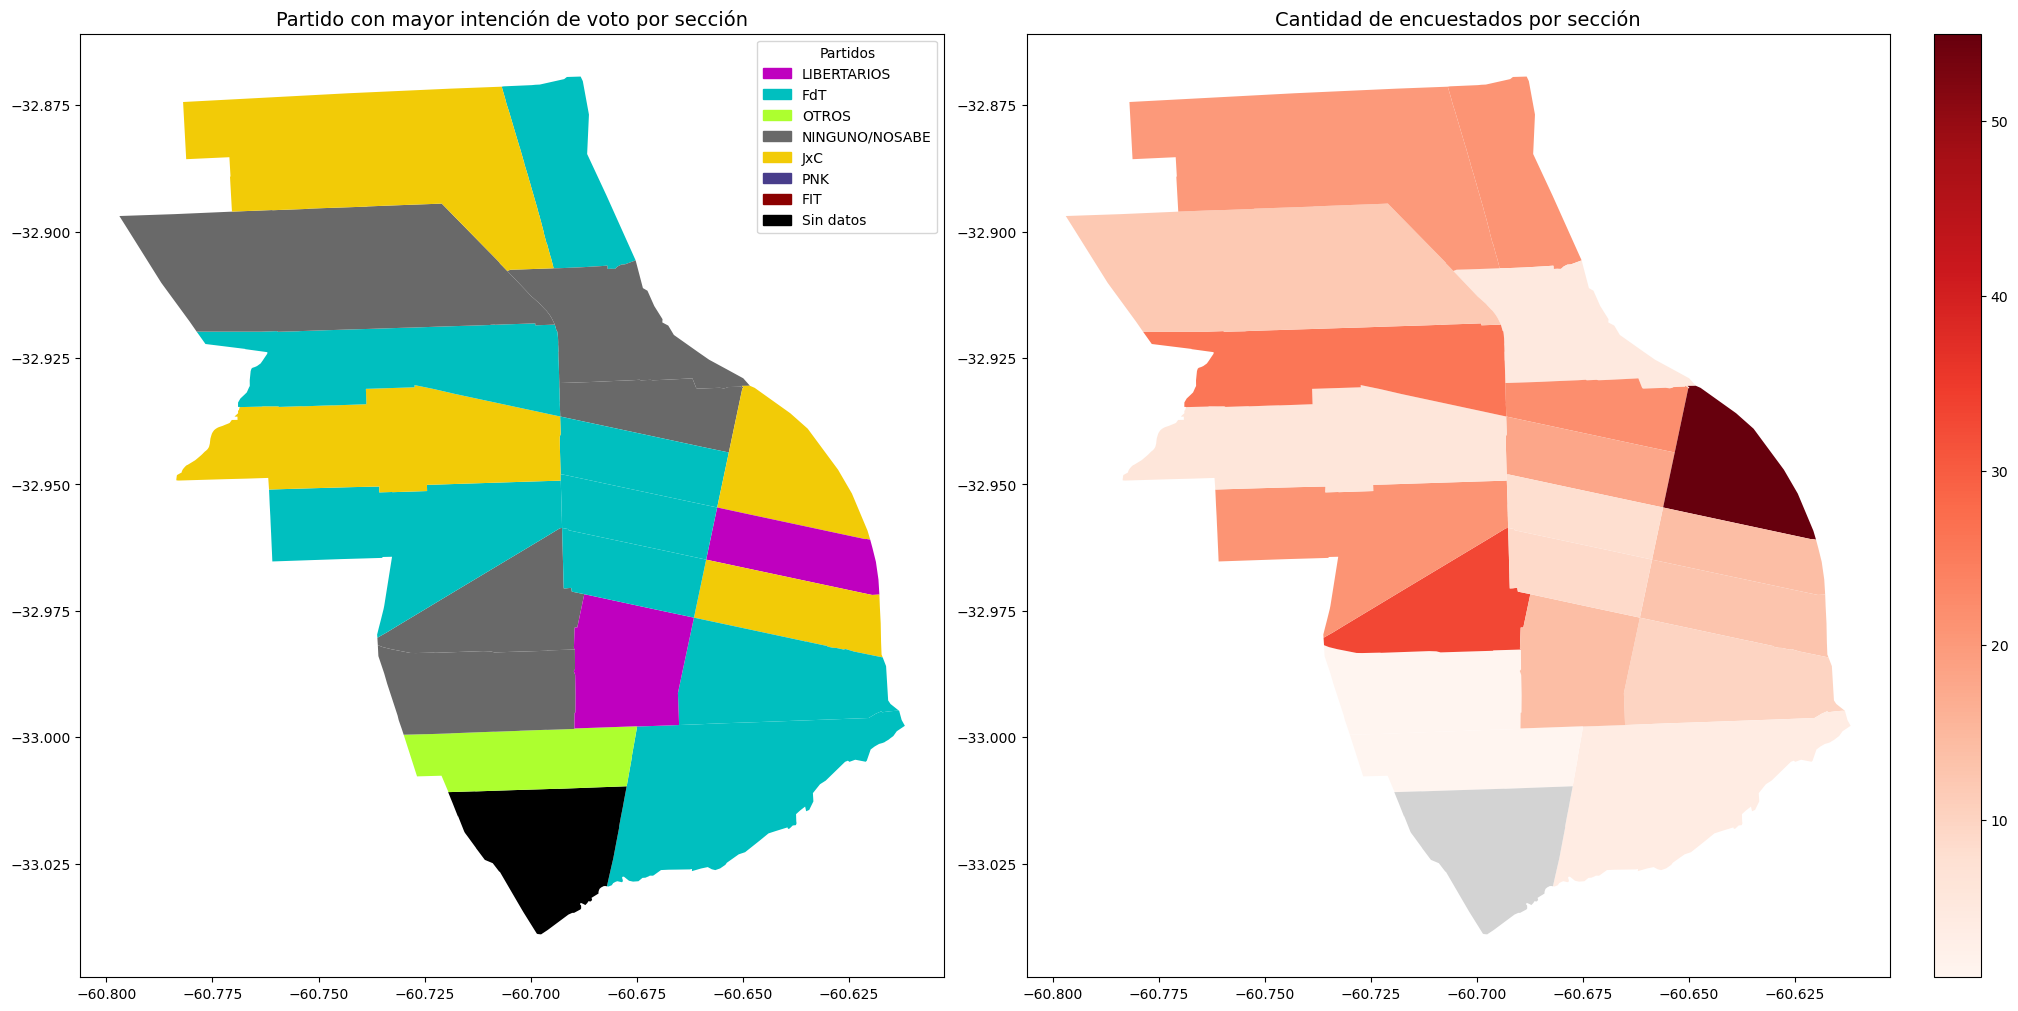

In [305]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)
secciones.plot(color=secciones['color'], ax=axes[0])
axes[0].set_title('Partido con mayor intención de voto por sección', fontsize=14)
leyenda = [mpatches.Patch(color=color, label=partido) for partido, color in colores_partidos.items()]
leyenda.append(mpatches.Patch(color='black', label='Sin datos'))
axes[0].legend(handles=leyenda, title='Partidos', loc='upper right', fontsize=10)
secciones.plot(
    column='cantidad_votos', 
    cmap='Reds', 
    legend=True, 
    ax=axes[1],
    missing_kwds={
        "color": "lightgrey",
        "label": "Sin datos"}
)
axes[1].set_title('Cantidad de encuestados por sección', fontsize=14)
plt.show()

In [306]:
conteo_votos = (
    uniondistritos.groupby(['DISTRITO', 'INT DE VOTO X ESPACIO'])
    .size()
    .reset_index(name='conteo')
)
mayor_votos_por_distrito = conteo_votos.loc[conteo_votos.groupby('DISTRITO')['conteo'].idxmax()]
distritos = distritos.merge(mayor_votos_por_distrito, on='DISTRITO', how='left')
distritos['color'] = distritos['INT DE VOTO X ESPACIO'].map(colores_partidos).fillna('black')
conteo_votos_por_distrito = (
    uniondistritos.groupby('DISTRITO')
    .size()
    .reset_index(name='cantidad_votos')
)
distritos = distritos.merge(conteo_votos_por_distrito, on='DISTRITO', how='left')

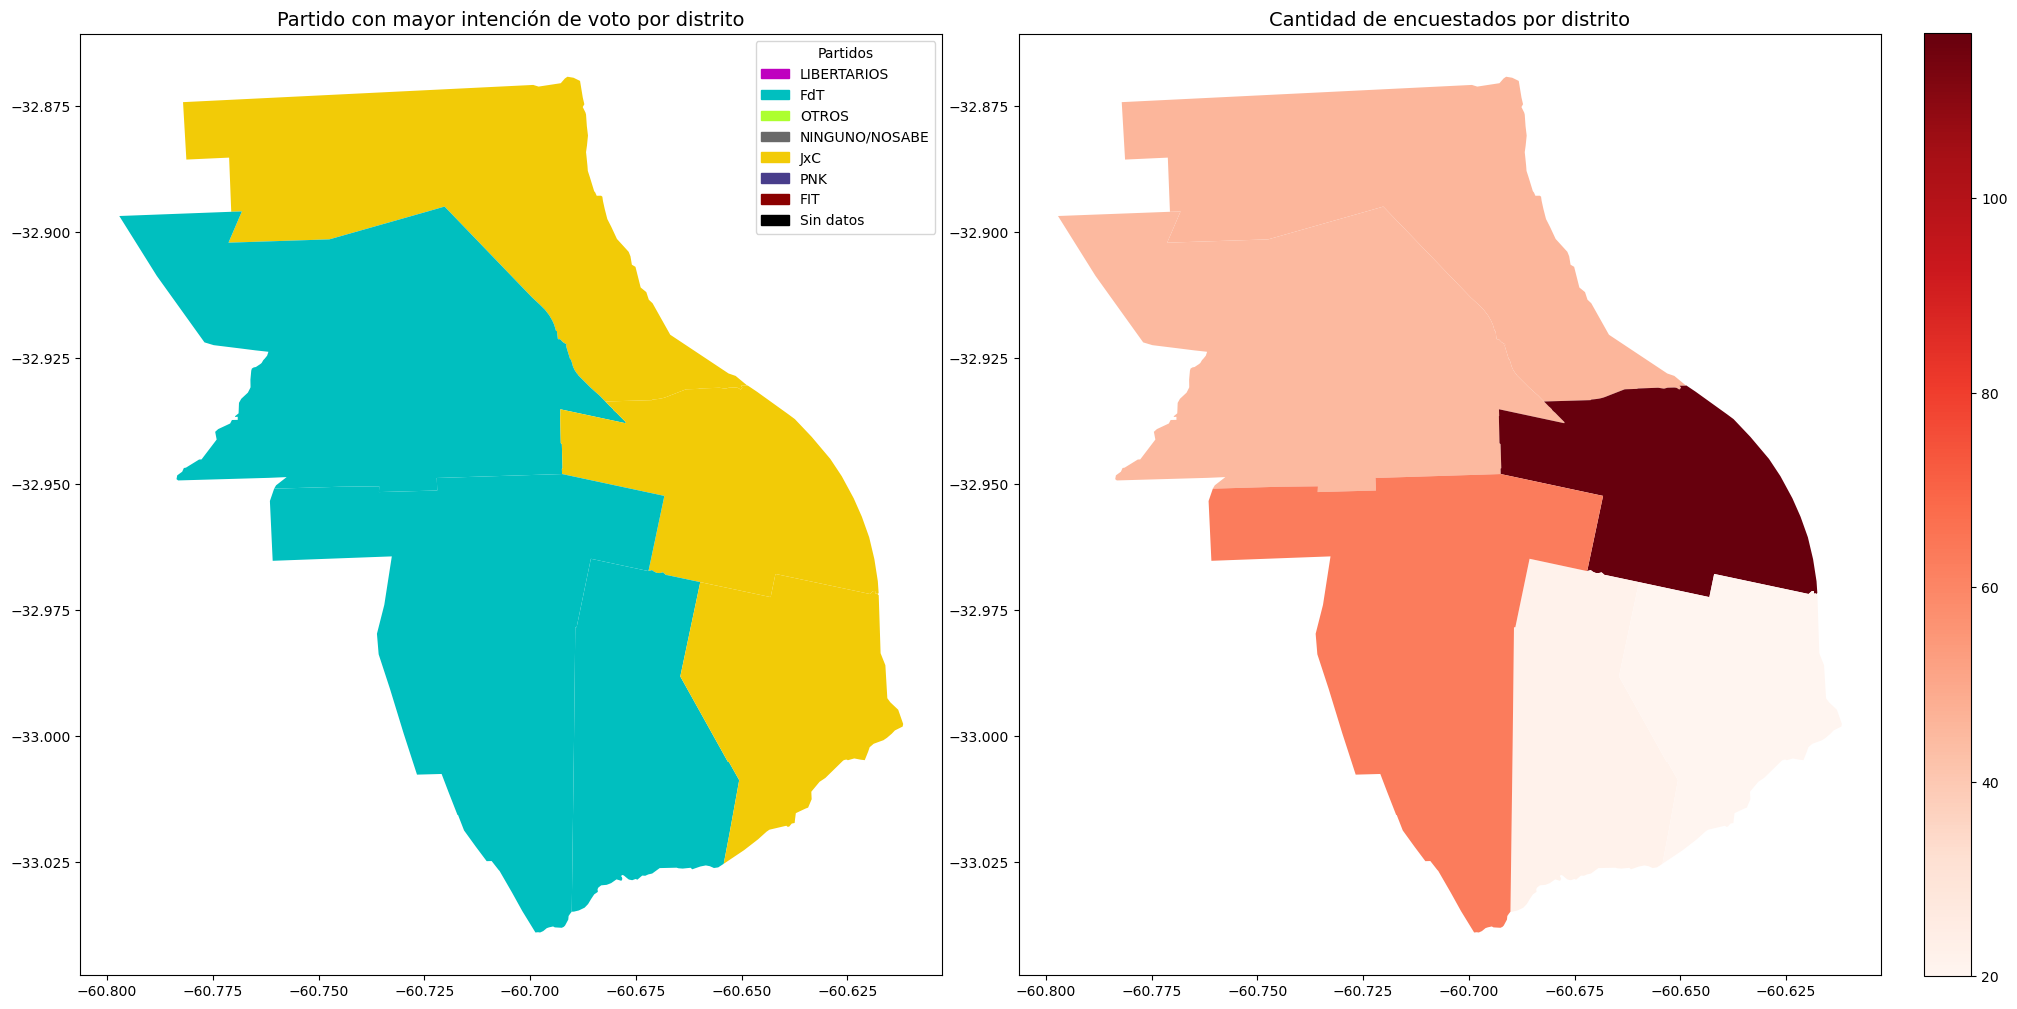

In [307]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)
distritos.plot(color=distritos['color'], ax=axes[0])
axes[0].set_title('Partido con mayor intención de voto por distrito', fontsize=14)
leyenda = [mpatches.Patch(color=color, label=partido) for partido, color in colores_partidos.items()]
leyenda.append(mpatches.Patch(color='black', label='Sin datos'))
axes[0].legend(handles=leyenda, title='Partidos', loc='upper right', fontsize=10)
distritos.plot(
    column='cantidad_votos', 
    cmap='Reds', 
    legend=True, 
    ax=axes[1],
    missing_kwds={
        "color": "lightgrey",
        "label": "Sin datos"}
)
axes[1].set_title('Cantidad de encuestados por distrito', fontsize=14)
plt.show()

### Segmentación por secciones y distritos

La segmentación por **secciones** aumentó la representatividad y mejoró la visualización en los mapas. Sin embargo, la *victoria de la categoría "Otros"* en varias secciones, junto con la existencia de zonas sin datos, indica que este no es el nivel de agrupación más adecuado para el análisis.  

Al pasar al nivel **distrital**, en cambio, se logran observar *dinámicas de voto más claras y agrupamientos representativos*. En particular, se distinguen dos tendencias territoriales relevantes:  
- El **corredor norte**, a lo largo de la ribera del río, muestra una marcada **preferencia por Juntos por el Cambio (JxC)**.  
- La **región suroeste** evidencia un mayor apoyo al **Frente de Todos (FdT)**.  


In [308]:
gdf_votos_fdt=union[union['INT DE VOTO X ESPACIO']=='FdT'] #agrupamiento FdT
conteo_votos_fdt = gdf_votos_fdt.groupby('BARRIO').size().reset_index(name='cantidad_votos_fdt')
barrios = barrios.merge(conteo_votos_fdt, on='BARRIO', how='left')
gdf_votos_fdt_dis=uniondistritos[uniondistritos['INT DE VOTO X ESPACIO']=='FdT']
conteo_votos_fdt_dis = gdf_votos_fdt_dis.groupby('DISTRITO').size().reset_index(name='cantidad_votos_fdt')
distritos = distritos.merge(conteo_votos_fdt_dis, on='DISTRITO', how='left')
gdf_votos_fdt_sec=unionseccion[unionseccion['INT DE VOTO X ESPACIO']=='FdT']
conteo_votos_fdt_sec = gdf_votos_fdt_sec.groupby('SECCION').size().reset_index(name='cantidad_votos_fdt')
secciones = secciones.merge(conteo_votos_fdt_sec, on='SECCION', how='left')
gdf_votos_jxc=union[union['INT DE VOTO X ESPACIO']=='JxC'] #agrupamiento JxC
conteo_votos_jxc = gdf_votos_jxc.groupby('BARRIO').size().reset_index(name='cantidad_votos_jxc')
barrios = barrios.merge(conteo_votos_jxc, on='BARRIO', how='left')
gdf_votos_jxc_dis=uniondistritos[uniondistritos['INT DE VOTO X ESPACIO']=='JxC']
conteo_votos_jxc_dis = gdf_votos_jxc_dis.groupby('DISTRITO').size().reset_index(name='cantidad_votos_jxc')
distritos = distritos.merge(conteo_votos_jxc_dis, on='DISTRITO', how='left')
gdf_votos_jxc_sec=unionseccion[unionseccion['INT DE VOTO X ESPACIO']=='JxC']
conteo_votos_jxc_sec = gdf_votos_jxc_sec.groupby('SECCION').size().reset_index(name='cantidad_votos_jxc')
secciones = secciones.merge(conteo_votos_jxc_sec, on='SECCION', how='left')
gdf_votos_lib=union[union['INT DE VOTO X ESPACIO']=='LIBERTARIOS'] #agrupamiento LLA
conteo_votos_lib = gdf_votos_lib.groupby('BARRIO').size().reset_index(name='cantidad_votos_lib')
barrios = barrios.merge(conteo_votos_lib, on='BARRIO', how='left')
gdf_votos_lib_dis=uniondistritos[uniondistritos['INT DE VOTO X ESPACIO']=='LIBERTARIOS']
conteo_votos_lib_dis = gdf_votos_lib_dis.groupby('DISTRITO').size().reset_index(name='cantidad_votos_lib')
distritos = distritos.merge(conteo_votos_lib_dis, on='DISTRITO', how='left')
gdf_votos_lib_sec=unionseccion[unionseccion['INT DE VOTO X ESPACIO']=='LIBERTARIOS']
conteo_votos_lib_sec = gdf_votos_lib_sec.groupby('SECCION').size().reset_index(name='cantidad_votos_lib')
secciones = secciones.merge(conteo_votos_lib_sec, on='SECCION', how='left')

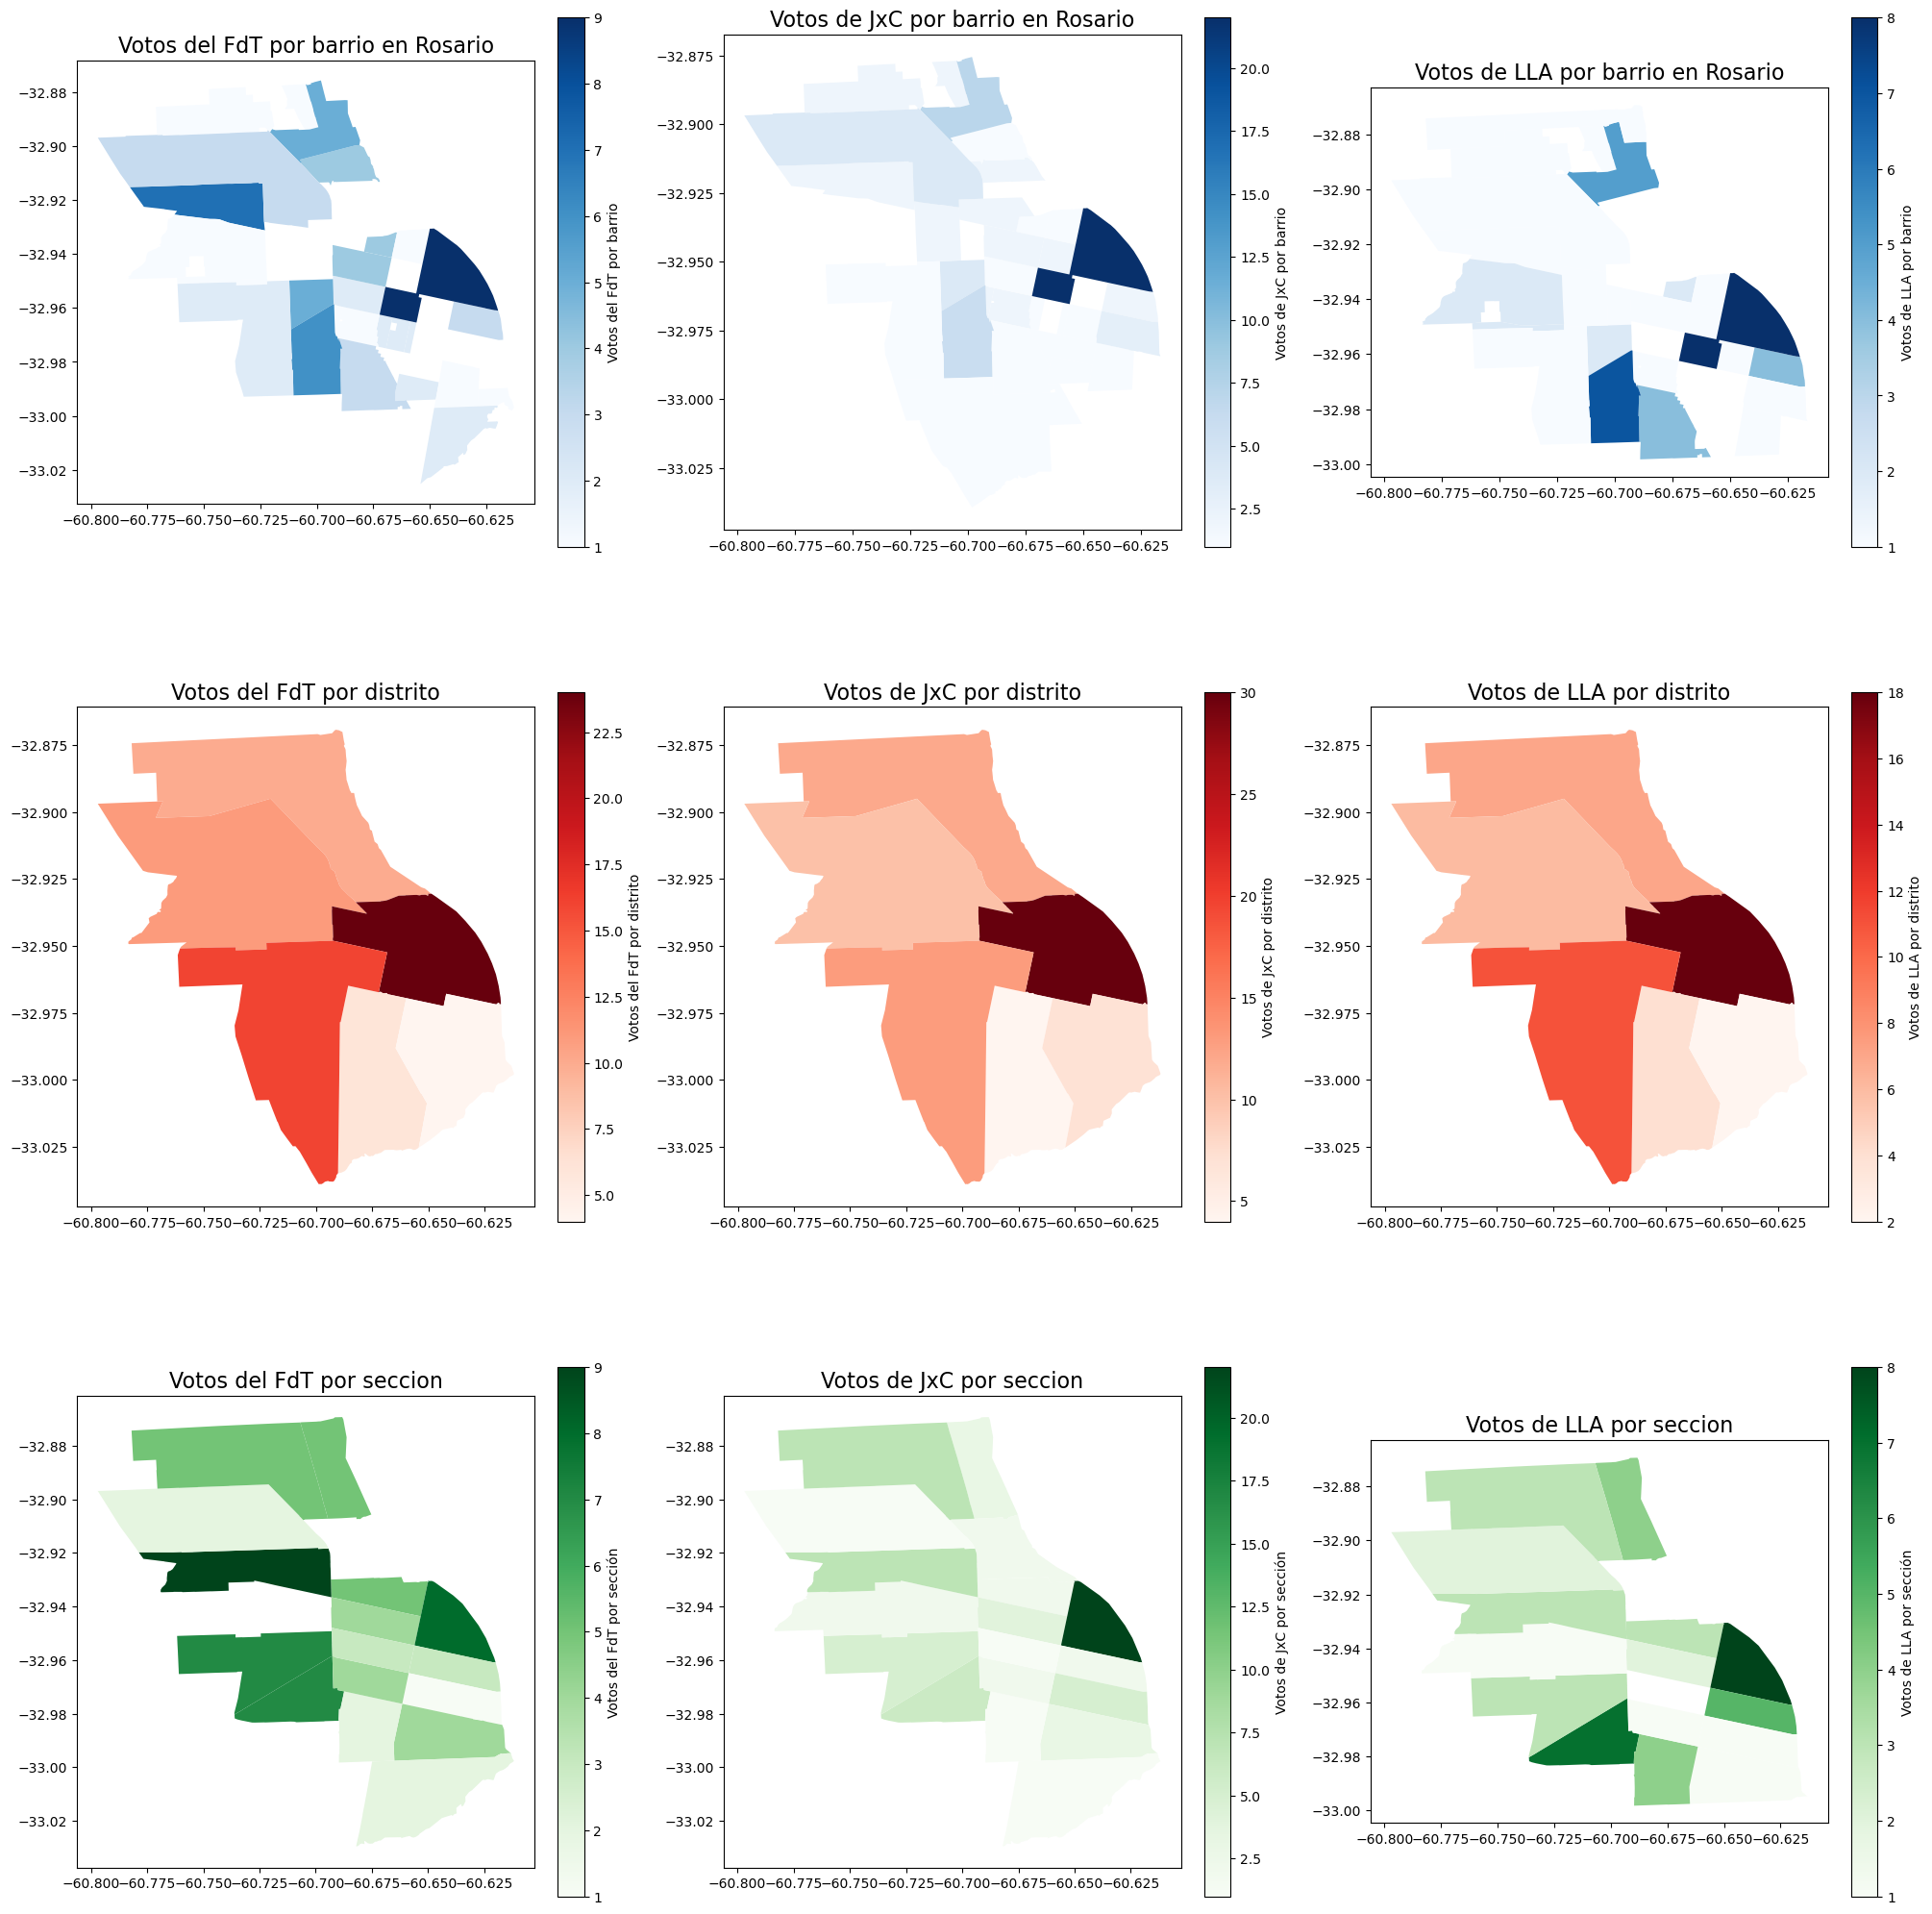

In [309]:
fig, axes = plt.subplots(3, 3, figsize=(20, 21), constrained_layout=True)
barrios.plot(column='cantidad_votos_fdt', ax=axes[0,0], legend=True, cmap='Blues', legend_kwds={'label': "Votos del FdT por barrio",'shrink': 0.8})
axes[0,0].set_title('Votos del FdT por barrio en Rosario', fontsize=16)
distritos.plot(column='cantidad_votos_fdt', ax=axes[1,0], legend=True,cmap='Reds', legend_kwds={'label':'Votos del FdT por distrito', 'shrink': 0.8})
axes[1,0].set_title('Votos del FdT por distrito', fontsize=16)
secciones.plot(column='cantidad_votos_fdt', ax=axes[2,0], legend=True, cmap='Greens', legend_kwds={'label':'Votos del FdT por sección', 'shrink': 0.8})
axes[2,0].set_title('Votos del FdT por seccion', fontsize=16)
barrios.plot(column='cantidad_votos_jxc', ax=axes[0,1], legend=True, cmap='Blues', legend_kwds={'label': "Votos de JxC por barrio", 'shrink': 0.8})
axes[0,1].set_title('Votos de JxC por barrio en Rosario', fontsize=16)
distritos.plot(column='cantidad_votos_jxc', ax=axes[1,1], legend=True,cmap='Reds', legend_kwds={'label':'Votos de JxC por distrito', 'shrink': 0.8})
axes[1,1].set_title('Votos de JxC por distrito', fontsize=16)
secciones.plot(column='cantidad_votos_jxc', ax=axes[2,1], legend=True, cmap='Greens', legend_kwds={'label':'Votos de JxC por sección', 'shrink': 0.8})
axes[2,1].set_title('Votos de JxC por seccion', fontsize=16)
barrios.plot(column='cantidad_votos_lib', ax=axes[0,2], legend=True, cmap='Blues', legend_kwds={'label': "Votos de LLA por barrio", 'shrink': 0.8})
axes[0,2].set_title('Votos de LLA por barrio en Rosario', fontsize=16)
distritos.plot(column='cantidad_votos_lib', ax=axes[1,2], legend=True,cmap='Reds', legend_kwds={'label':'Votos de LLA por distrito', 'shrink': 0.8})
axes[1,2].set_title('Votos de LLA por distrito', fontsize=16)
secciones.plot(column='cantidad_votos_lib', ax=axes[2,2], legend=True, cmap='Greens', legend_kwds={'label':'Votos de LLA por sección', 'shrink': 0.8})
axes[2,2].set_title('Votos de LLA por seccion', fontsize=16)
plt.show()

In [310]:
gdf_votos_fit=union[union['INT DE VOTO X ESPACIO']=='FIT']
conteo_votos_fit = gdf_votos_fit.groupby('BARRIO').size().reset_index(name='cantidad_votos_fit')
barrios = barrios.merge(conteo_votos_fit, on='BARRIO', how='left')
gdf_votos_fit_dis=uniondistritos[uniondistritos['INT DE VOTO X ESPACIO']=='FIT']
conteo_votos_fit_dis = gdf_votos_fit_dis.groupby('DISTRITO').size().reset_index(name='cantidad_votos_fit')
distritos = distritos.merge(conteo_votos_fit_dis, on='DISTRITO', how='left')
gdf_votos_fit_sec=unionseccion[unionseccion['INT DE VOTO X ESPACIO']=='FIT']
conteo_votos_fit_sec = gdf_votos_fit_sec.groupby('SECCION').size().reset_index(name='cantidad_votos_fit')
secciones = secciones.merge(conteo_votos_fit_sec, on='SECCION', how='left')

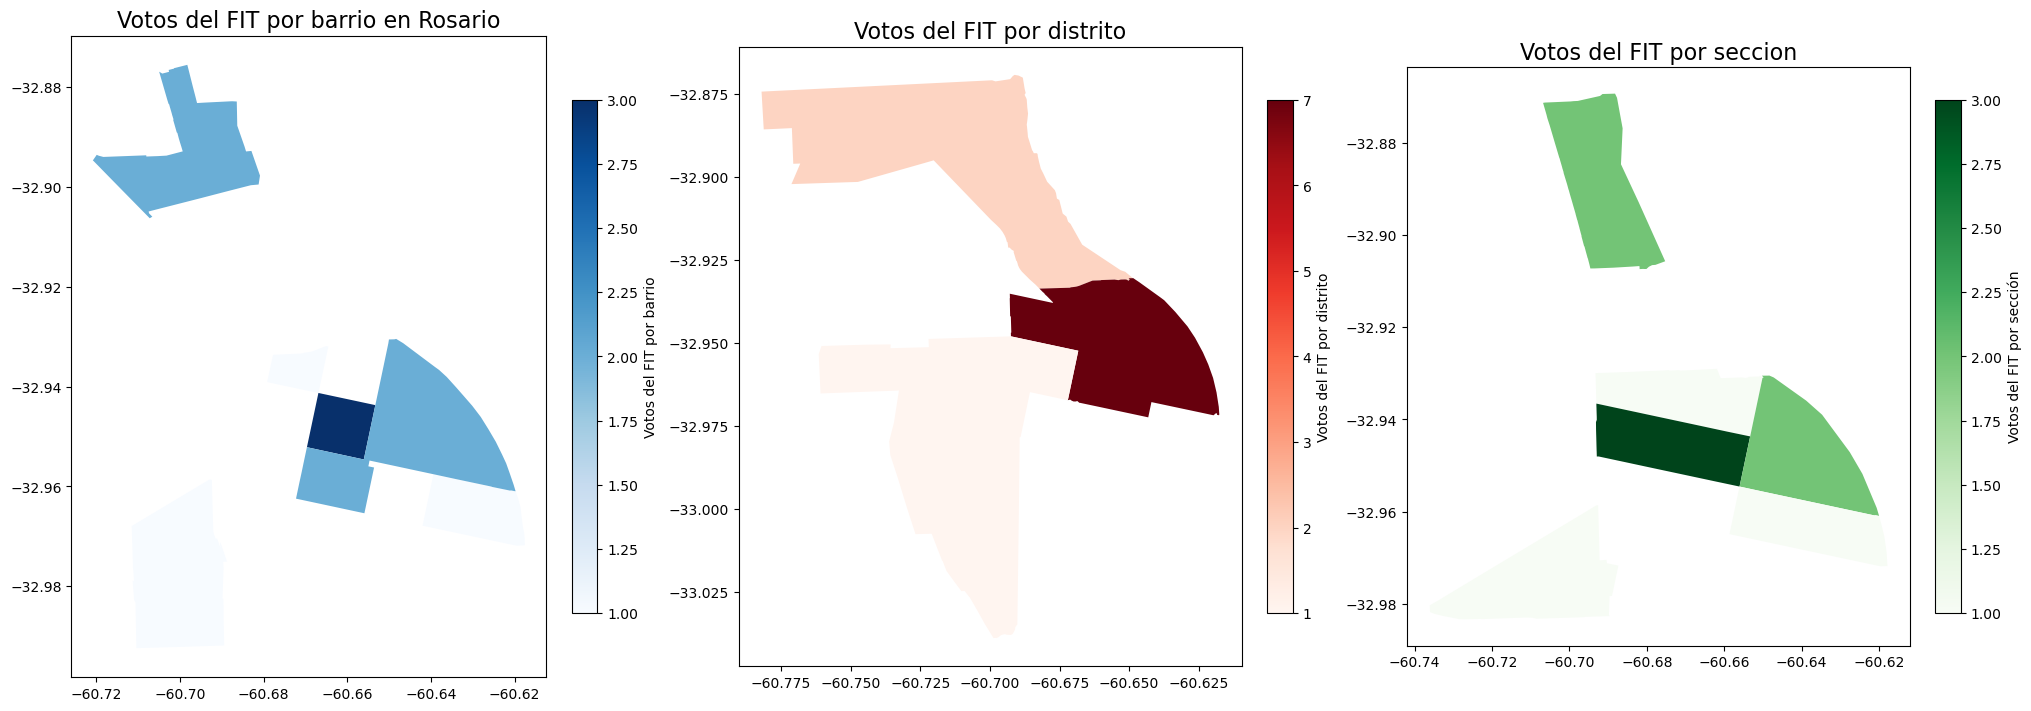

In [311]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
barrios.plot(column='cantidad_votos_fit', ax=axes[0], legend=True, cmap='Blues', legend_kwds={'label': "Votos del FIT por barrio", 'shrink': 0.8})
axes[0].set_title('Votos del FIT por barrio en Rosario', fontsize=16)
distritos.plot(column='cantidad_votos_fit', ax=axes[1], legend=True,cmap='Reds', legend_kwds={'label':'Votos del FIT por distrito', 'shrink': 0.8})
axes[1].set_title('Votos del FIT por distrito', fontsize=16)
secciones.plot(column='cantidad_votos_fit', ax=axes[2], legend=True, cmap='Greens', legend_kwds={'label':'Votos del FIT por sección', 'shrink': 0.8})
axes[2].set_title('Votos del FIT por seccion', fontsize=16)
plt.show()

In [312]:
gdf_votos_pnk=union[union['INT DE VOTO X ESPACIO']=='PNK']
conteo_votos_pnk = gdf_votos_pnk.groupby('BARRIO').size().reset_index(name='cantidad_votos_pnk')
barrios = barrios.merge(conteo_votos_pnk, on='BARRIO', how='left')
gdf_votos_pnk_dis=uniondistritos[uniondistritos['INT DE VOTO X ESPACIO']=='PNK']
conteo_votos_pnk_dis = gdf_votos_pnk_dis.groupby('DISTRITO').size().reset_index(name='cantidad_votos_pnk')
distritos = distritos.merge(conteo_votos_pnk_dis, on='DISTRITO', how='left')
gdf_votos_pnk_sec=unionseccion[unionseccion['INT DE VOTO X ESPACIO']=='PNK']
conteo_votos_pnk_sec = gdf_votos_pnk_sec.groupby('SECCION').size().reset_index(name='cantidad_votos_pnk')
secciones = secciones.merge(conteo_votos_pnk_sec, on='SECCION', how='left')

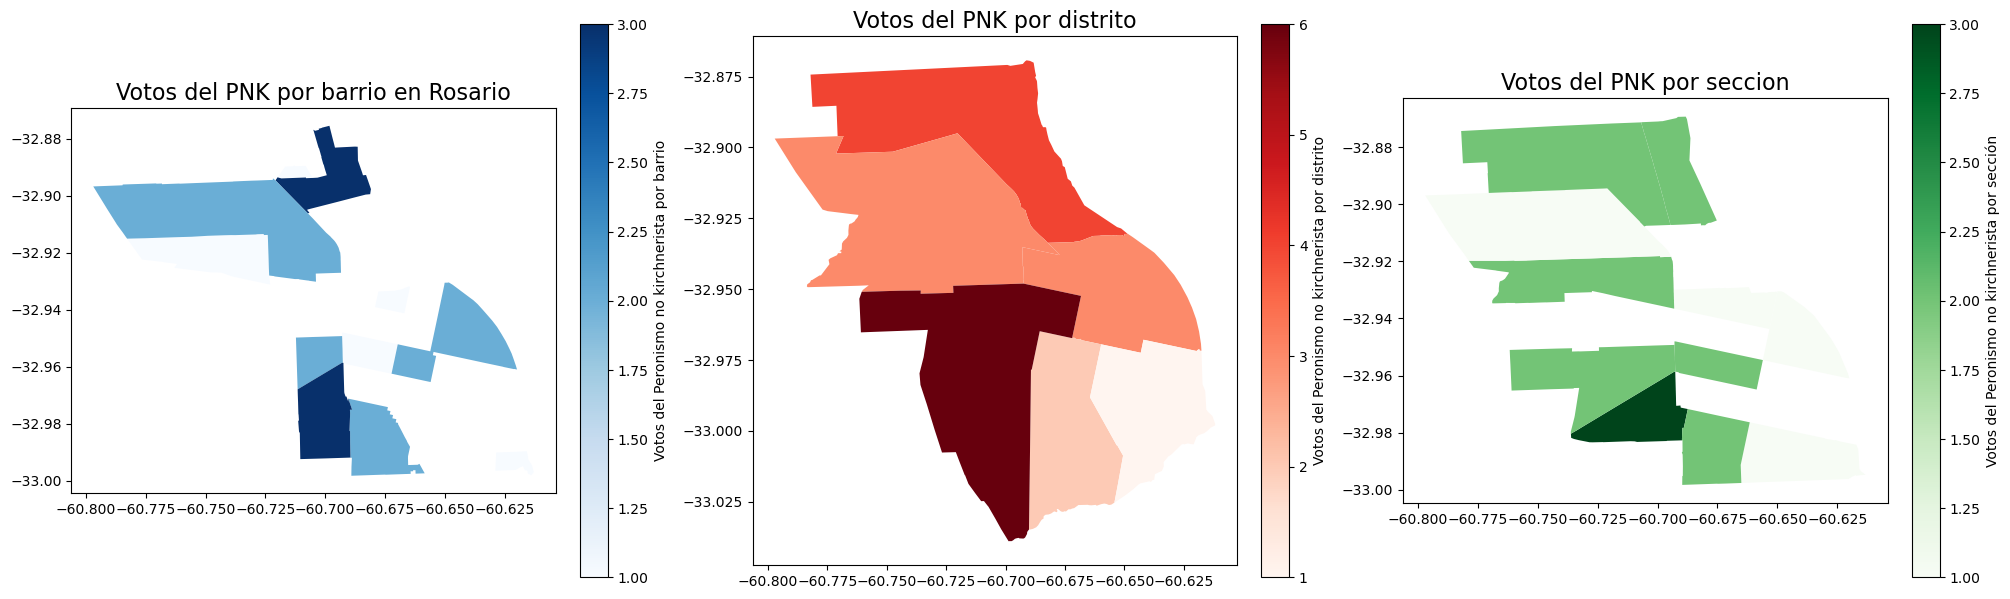

In [313]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
barrios.plot(column='cantidad_votos_pnk', ax=axes[0], legend=True, cmap='Blues', legend_kwds={'label': "Votos del Peronismo no kirchnerista por barrio", 'shrink': 0.8})
axes[0].set_title('Votos del PNK por barrio en Rosario', fontsize=16)
distritos.plot(column='cantidad_votos_pnk', ax=axes[1], legend=True,cmap='Reds', legend_kwds={'label':'Votos del Peronismo no kirchnerista por distrito', 'shrink': 0.8})
axes[1].set_title('Votos del PNK por distrito', fontsize=16)
secciones.plot(column='cantidad_votos_pnk', ax=axes[2], legend=True, cmap='Greens', legend_kwds={'label':'Votos del Peronismo no kirchnerista por sección', 'shrink': 0.8})
axes[2].set_title('Votos del PNK por seccion', fontsize=16)
plt.show()

In [314]:
gdf_votos_ns=union[union['INT DE VOTO X ESPACIO']=='NINGUNO/NOSABE']
conteo_votos_ns = gdf_votos_ns.groupby('BARRIO').size().reset_index(name='cantidad_votos_ns')
barrios = barrios.merge(conteo_votos_ns, on='BARRIO', how='left')
gdf_votos_ns_dis=uniondistritos[uniondistritos['INT DE VOTO X ESPACIO']=='NINGUNO/NOSABE']
conteo_votos_ns_dis = gdf_votos_ns_dis.groupby('DISTRITO').size().reset_index(name='cantidad_votos_ns')
distritos = distritos.merge(conteo_votos_ns_dis, on='DISTRITO', how='left')
gdf_votos_ns_sec=unionseccion[unionseccion['INT DE VOTO X ESPACIO']=='NINGUNO/NOSABE']
conteo_votos_ns_sec = gdf_votos_ns_sec.groupby('SECCION').size().reset_index(name='cantidad_votos_ns')
secciones = secciones.merge(conteo_votos_ns_sec, on='SECCION', how='left')

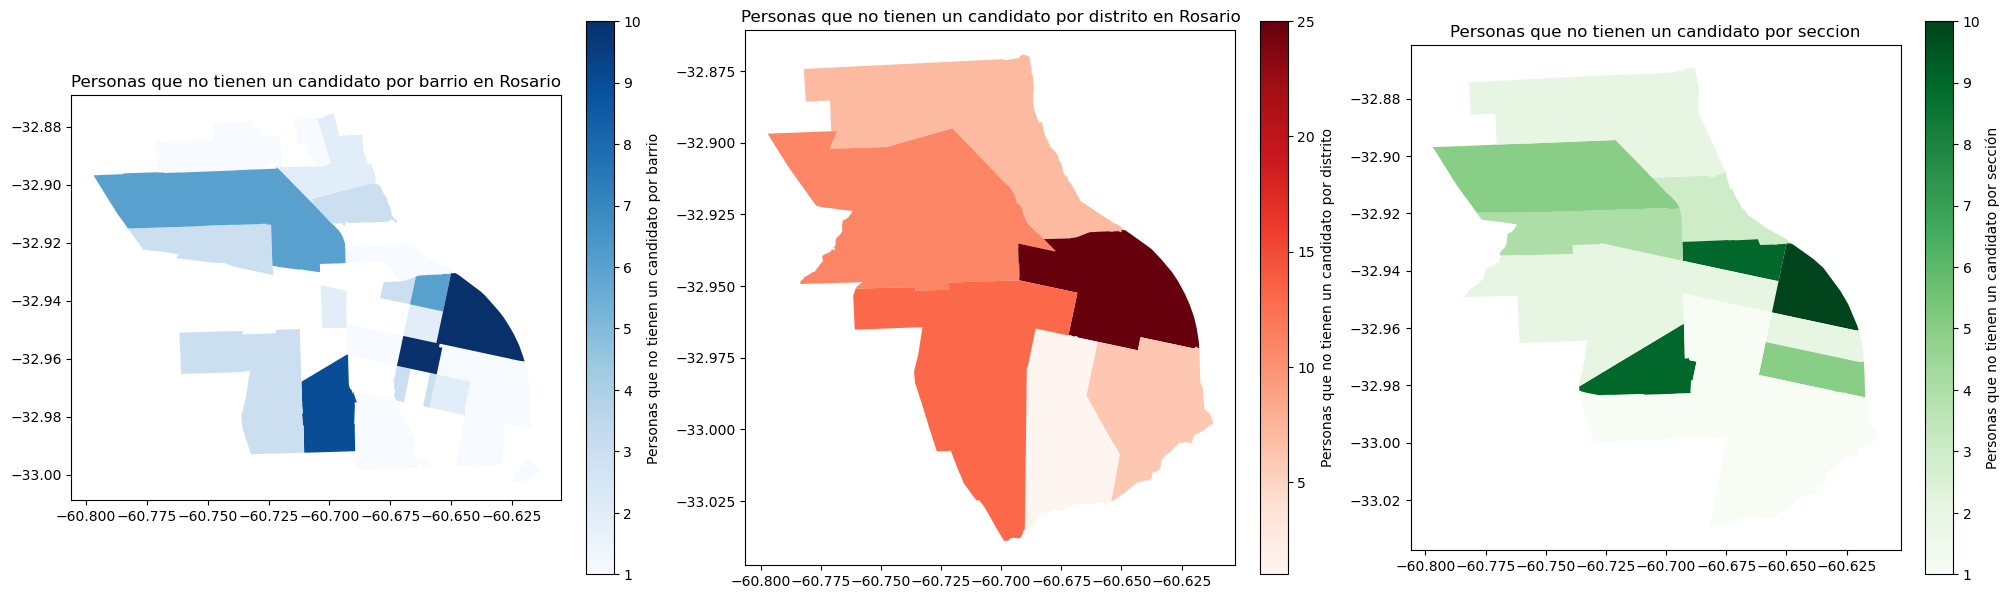

In [315]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
barrios.plot(column='cantidad_votos_ns', ax=axes[0], legend=True, cmap='Blues', legend_kwds={'label': "Personas que no tienen un candidato por barrio", 'shrink': 0.8})
axes[0].set_title('Personas que no tienen un candidato por barrio en Rosario', fontsize=12)
distritos.plot(column='cantidad_votos_ns', ax=axes[1], legend=True,cmap='Reds', legend_kwds={'label':'Personas que no tienen un candidato por distrito', 'shrink': 0.8})
axes[1].set_title('Personas que no tienen un candidato por distrito en Rosario', fontsize=12)
secciones.plot(column='cantidad_votos_ns', ax=axes[2], legend=True, cmap='Greens', legend_kwds={'label':'Personas que no tienen un candidato por sección', 'shrink': 0.8})
axes[2].set_title('Personas que no tienen un candidato por seccion', fontsize=12)
plt.show()

In [316]:
gdf_votos_otros=union[union['INT DE VOTO X ESPACIO']=='OTROS']
conteo_votos_otros = gdf_votos_otros.groupby('BARRIO').size().reset_index(name='cantidad_votos_otros')
barrios = barrios.merge(conteo_votos_otros, on='BARRIO', how='left')
gdf_votos_otros_dis=uniondistritos[uniondistritos['INT DE VOTO X ESPACIO']=='OTROS']
conteo_votos_otros_dis = gdf_votos_otros_dis.groupby('DISTRITO').size().reset_index(name='cantidad_votos_otros')
distritos = distritos.merge(conteo_votos_otros_dis, on='DISTRITO', how='left')
gdf_votos_otros_sec=unionseccion[unionseccion['INT DE VOTO X ESPACIO']=='OTROS']
conteo_votos_otros_sec = gdf_votos_otros_sec.groupby('SECCION').size().reset_index(name='cantidad_votos_otros')
secciones = secciones.merge(conteo_votos_otros_sec, on='SECCION', how='left')

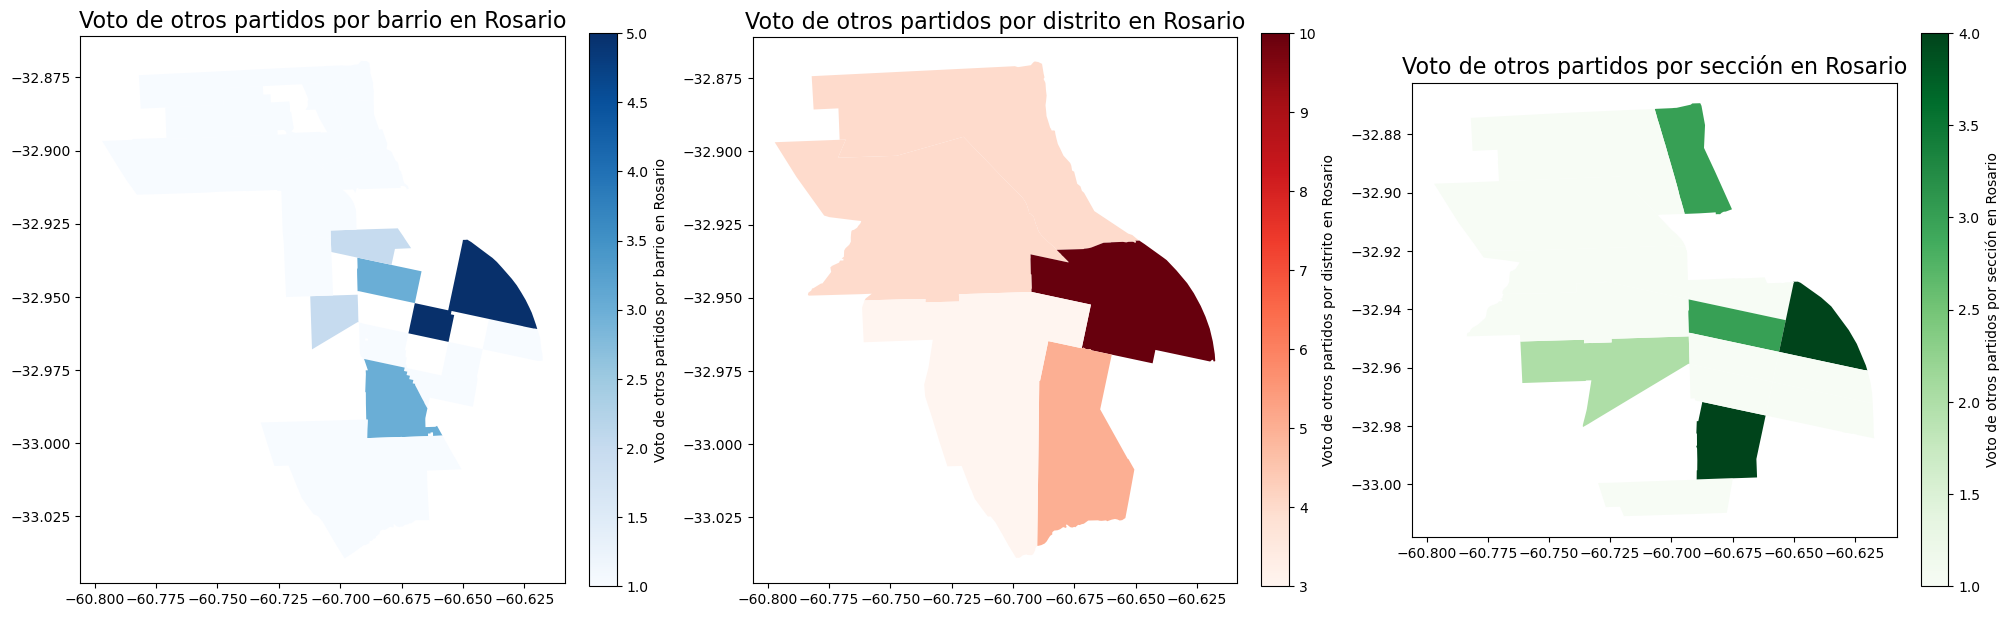

In [317]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
barrios.plot(column='cantidad_votos_otros', ax=axes[0], legend=True, cmap='Blues', legend_kwds={'label': "Voto de otros partidos por barrio en Rosario", 'shrink': 0.8})
axes[0].set_title('Voto de otros partidos por barrio en Rosario', fontsize=16)
distritos.plot(column='cantidad_votos_otros', ax=axes[1], legend=True,cmap='Reds', legend_kwds={'label':'Voto de otros partidos por distrito en Rosario', 'shrink': 0.8})
axes[1].set_title('Voto de otros partidos por distrito en Rosario', fontsize=16)
secciones.plot(column='cantidad_votos_otros', ax=axes[2], legend=True, cmap='Greens', legend_kwds={'label':'Voto de otros partidos por sección en Rosario', 'shrink': 0.8})
axes[2].set_title('Voto de otros partidos por sección en Rosario', fontsize=16)
plt.show()

In [318]:
estratos['Geometría en GeoJSON'] = estratos['Geometría en GeoJSON'].apply(lambda x: shape(json.loads(x)))
estratos=estratos.set_geometry('Geometría en GeoJSON')
estratos=gpd.GeoDataFrame(estratos, geometry='Geometría en GeoJSON', crs='EPSG:4326')
estratos = estratos.dropna(subset=['Latitud del centroide', 'Longitud del centroide'])
estratos = estratos.dropna(subset=["Segmento socioeconómico del radio"])
estratos = estratos.dropna(subset=['Geometría en GeoJSON'])
estratos['Segmento socioeconómico del radio']
estratos['Segmento socioeconómico del radio'] = estratos['Segmento socioeconómico del radio'].astype(int)

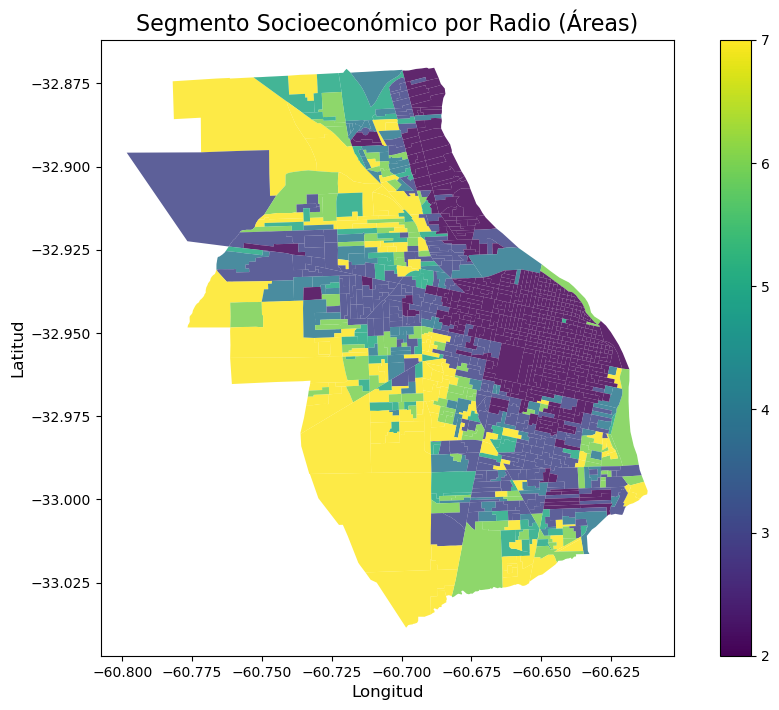

In [319]:
fig, ax = plt.subplots(figsize=(12, 8))
estratos.plot(column='Segmento socioeconómico del radio', ax=ax, legend=True, cmap='viridis', alpha=0.85)  # alpha controla la opacidad del área
ax.set_title('Segmento Socioeconómico por Radio (Áreas)', fontsize=16)
ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)
plt.show()

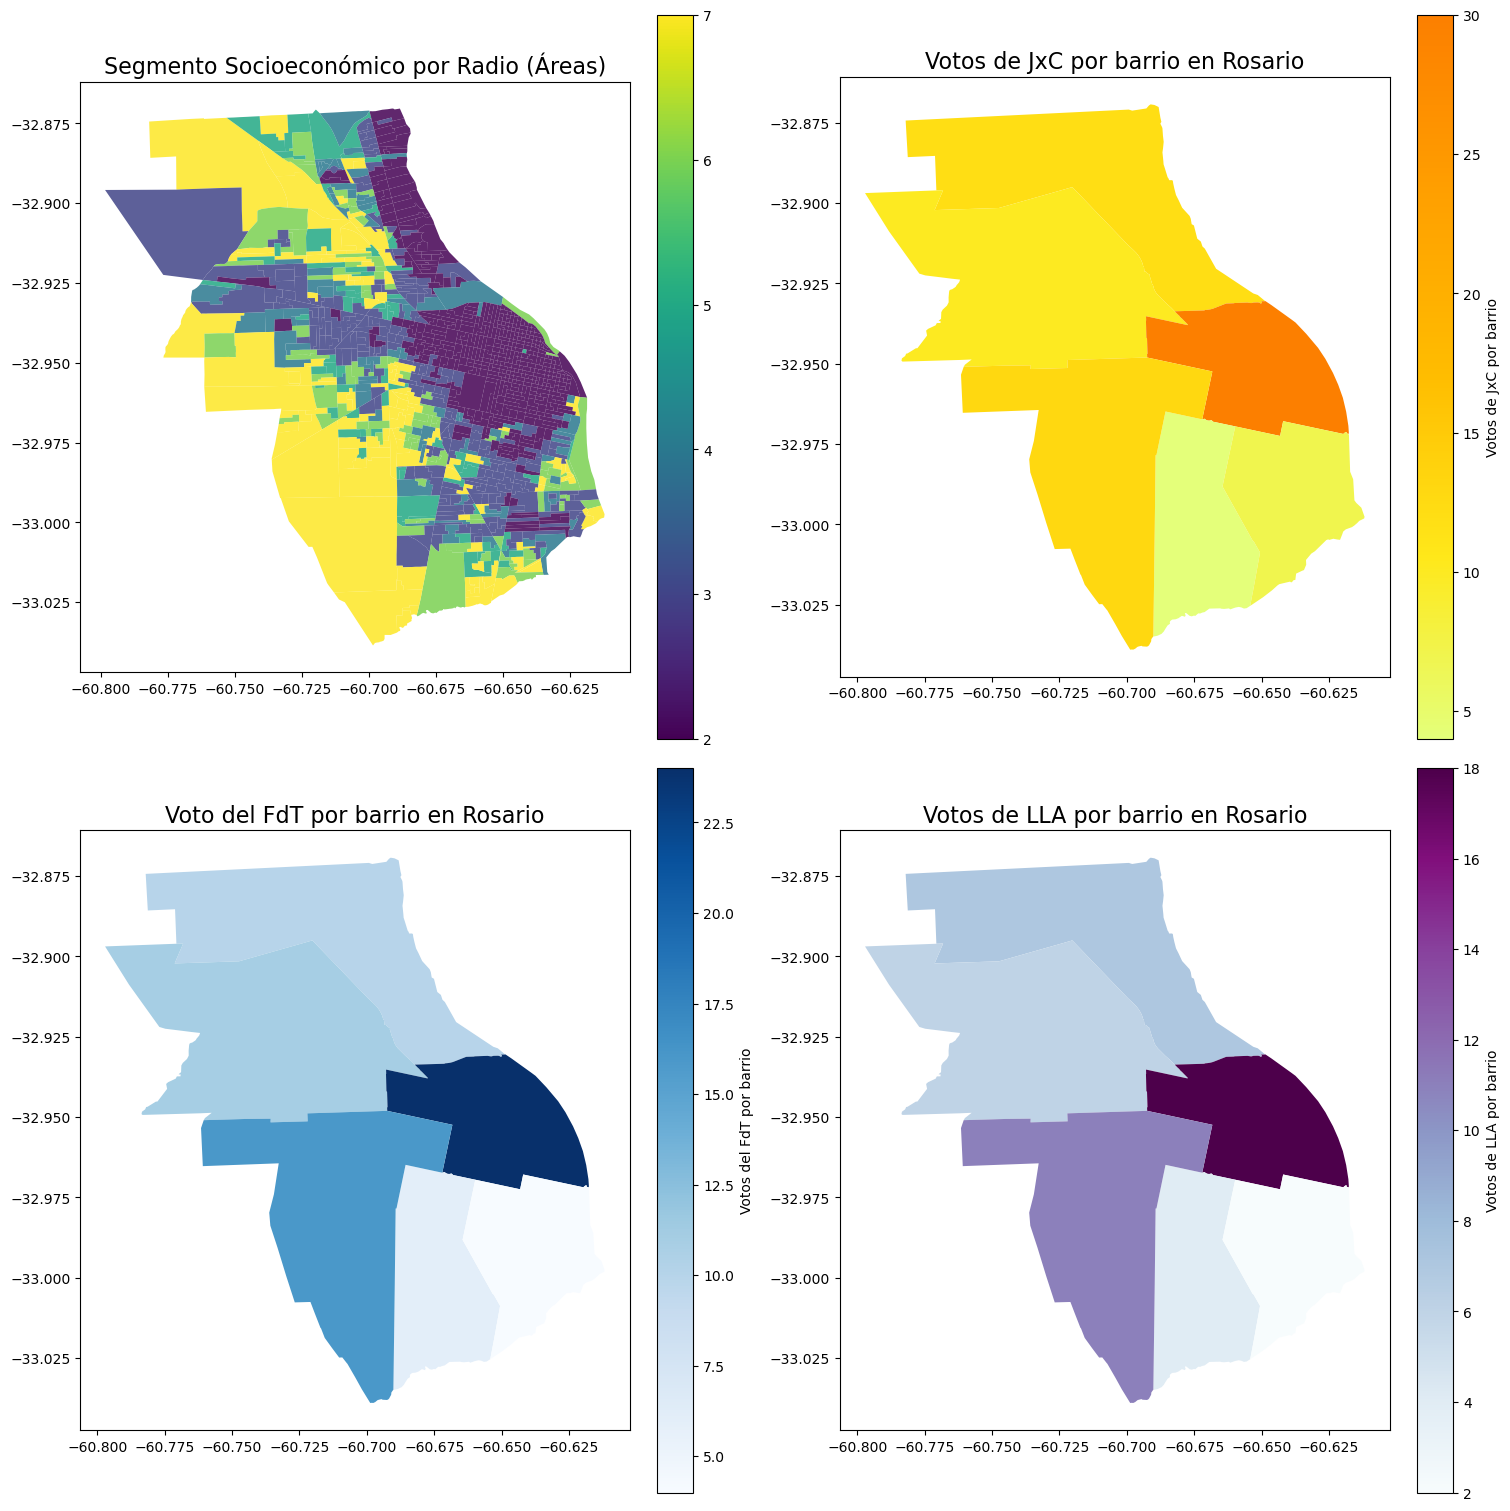

In [320]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15), constrained_layout=True)
distritos.plot(column='cantidad_votos_fdt', ax=axes[1,0], legend=True, cmap='Blues', legend_kwds={'label': "Votos del FdT por barrio"})
axes[1,0].set_title('Voto del FdT por barrio en Rosario', fontsize=16)
estratos.plot(column='Segmento socioeconómico del radio', ax=axes[0,0], legend=True, cmap='viridis', alpha=0.85)
axes[0,0].set_title('Segmento Socioeconómico por Radio (Áreas)', fontsize=16)
distritos.plot(column='cantidad_votos_jxc', ax=axes[0,1], legend=True, cmap='Wistia', legend_kwds={'label': "Votos de JxC por barrio"})
axes[0,1].set_title('Votos de JxC por barrio en Rosario', fontsize=16)
distritos.plot(column='cantidad_votos_lib', ax=axes[1,1], legend=True, cmap='BuPu', legend_kwds={'label': "Votos de LLA por barrio"})
axes[1,1].set_title('Votos de LLA por barrio en Rosario', fontsize=16)
plt.show()

In [321]:
niveleducativo['Geometría en GeoJSON'] = niveleducativo['Geometría en GeoJSON'].apply(lambda x: shape(json.loads(x)))
niveleducativo=niveleducativo.set_geometry('Geometría en GeoJSON')
niveleducativo=gpd.GeoDataFrame(niveleducativo, geometry='Geometría en GeoJSON', crs='EPSG:4326')
niveleducativo = niveleducativo.dropna(subset=['Latitud del centroide', 'Longitud del centroide'])
niveleducativo = niveleducativo.dropna(subset=['Población de 18 y más con primaria incompleta o menos'])
niveleducativo = niveleducativo.dropna(subset=['Población de 18 y más con universitario completo o más'])
niveleducativo = niveleducativo.dropna(subset=['Geometría en GeoJSON'])
niveleducativo['Población de 18 y más con primaria incompleta o menos']
niveleducativo['Población de 18 y más con primaria incompleta o menos'] = niveleducativo['Población de 18 y más con primaria incompleta o menos'].astype(int)
niveleducativo['Población de 18 y más con universitario completo o más']
niveleducativo['Población de 18 y más con universitario completo o más'] = niveleducativo['Población de 18 y más con universitario completo o más'].astype(int)

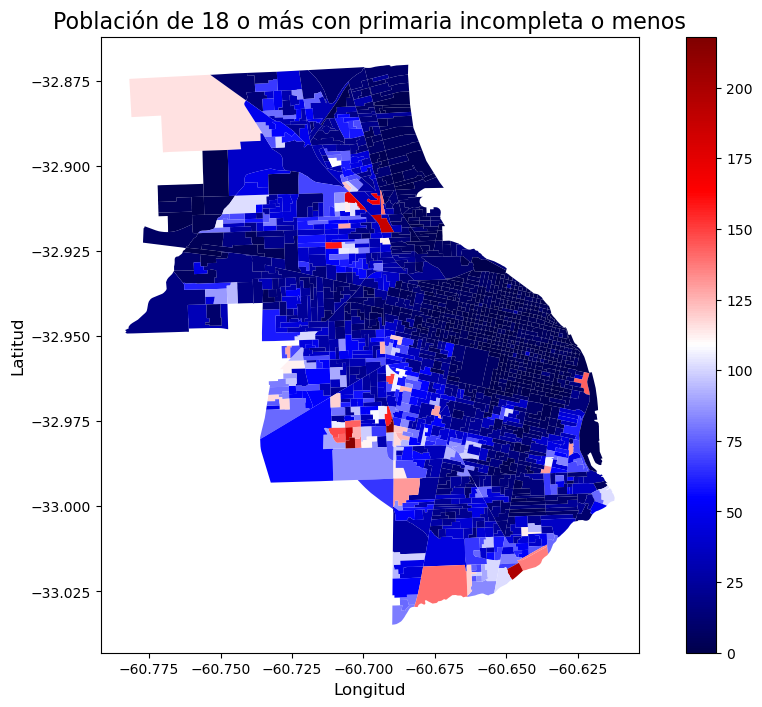

In [322]:
fig, ax = plt.subplots(figsize=(12, 8))
niveleducativo.plot(column='Población de 18 y más con primaria incompleta o menos', ax=ax, legend=True, cmap='seismic', alpha=1)  # alpha controla la opacidad del área
ax.set_title('Población de 18 o más con primaria incompleta o menos', fontsize=16)
ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)
plt.show()

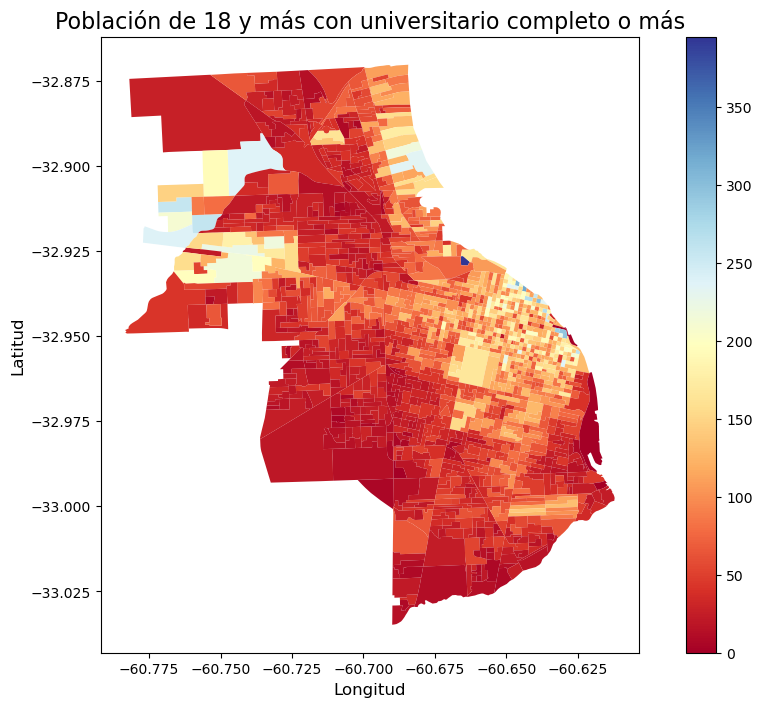

In [323]:
fig, ax = plt.subplots(figsize=(12, 8))
niveleducativo.plot(column='Población de 18 y más con universitario completo o más', ax=ax, legend=True, cmap='RdYlBu', alpha=1)
ax.set_title('Población de 18 y más con universitario completo o más', fontsize=16)
ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)
plt.show()

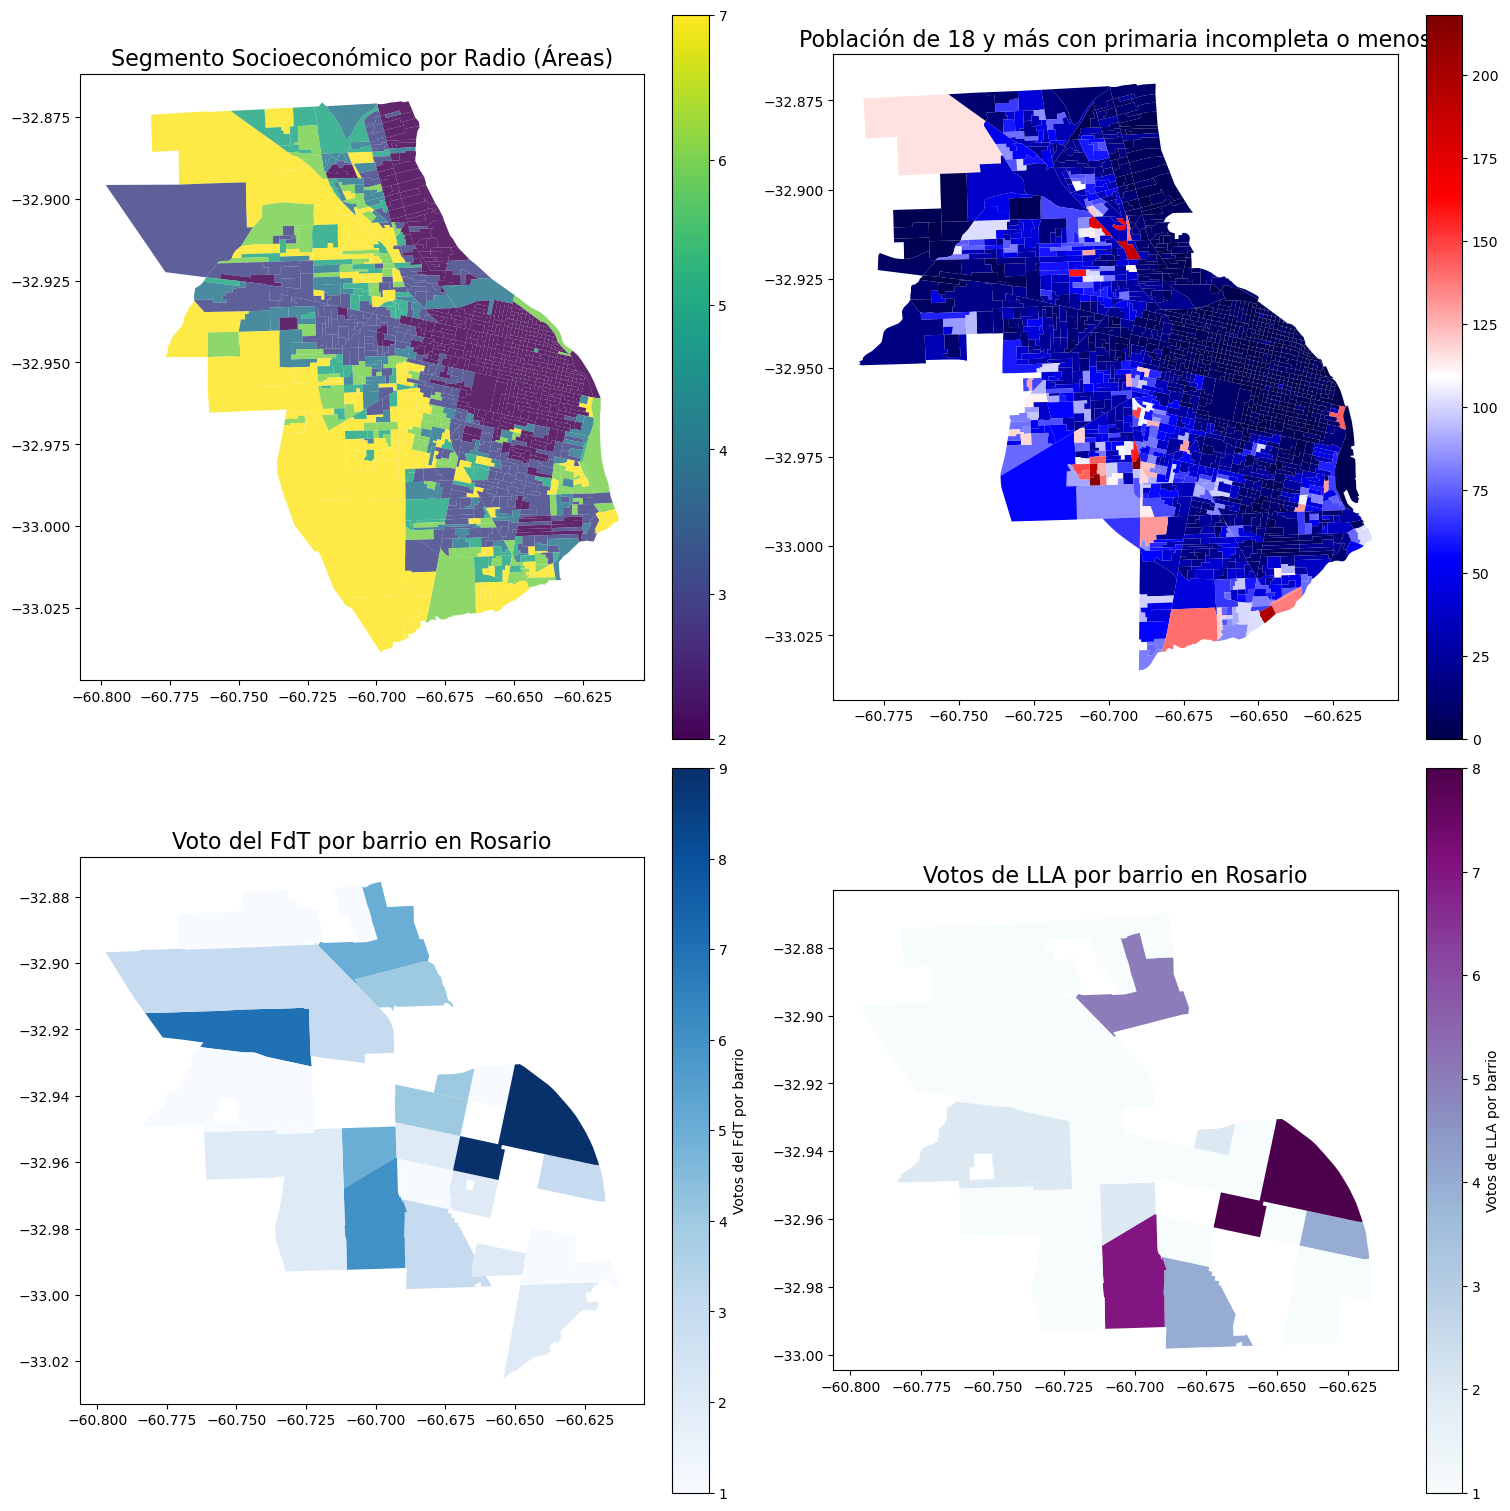

In [324]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15), constrained_layout=True)
barrios.plot(column='cantidad_votos_fdt', ax=axes[1,0], legend=True, cmap='Blues', legend_kwds={'label': "Votos del FdT por barrio"})
axes[1,0].set_title('Voto del FdT por barrio en Rosario', fontsize=16)
estratos.plot(column='Segmento socioeconómico del radio', ax=axes[0,0], legend=True, cmap='viridis', alpha=0.85)
axes[0,0].set_title('Segmento Socioeconómico por Radio (Áreas)', fontsize=16)
niveleducativo.plot(column='Población de 18 y más con primaria incompleta o menos', ax=axes[0,1], legend=True, cmap='seismic', alpha=1)  # alpha controla la opacidad del área
axes[0,1].set_title('Población de 18 y más con primaria incompleta o menos', fontsize=16)
barrios.plot(column='cantidad_votos_lib', ax=axes[1,1], legend=True, cmap='BuPu', legend_kwds={'label': "Votos de LLA por barrio"})
axes[1,1].set_title('Votos de LLA por barrio en Rosario', fontsize=16)
plt.show()

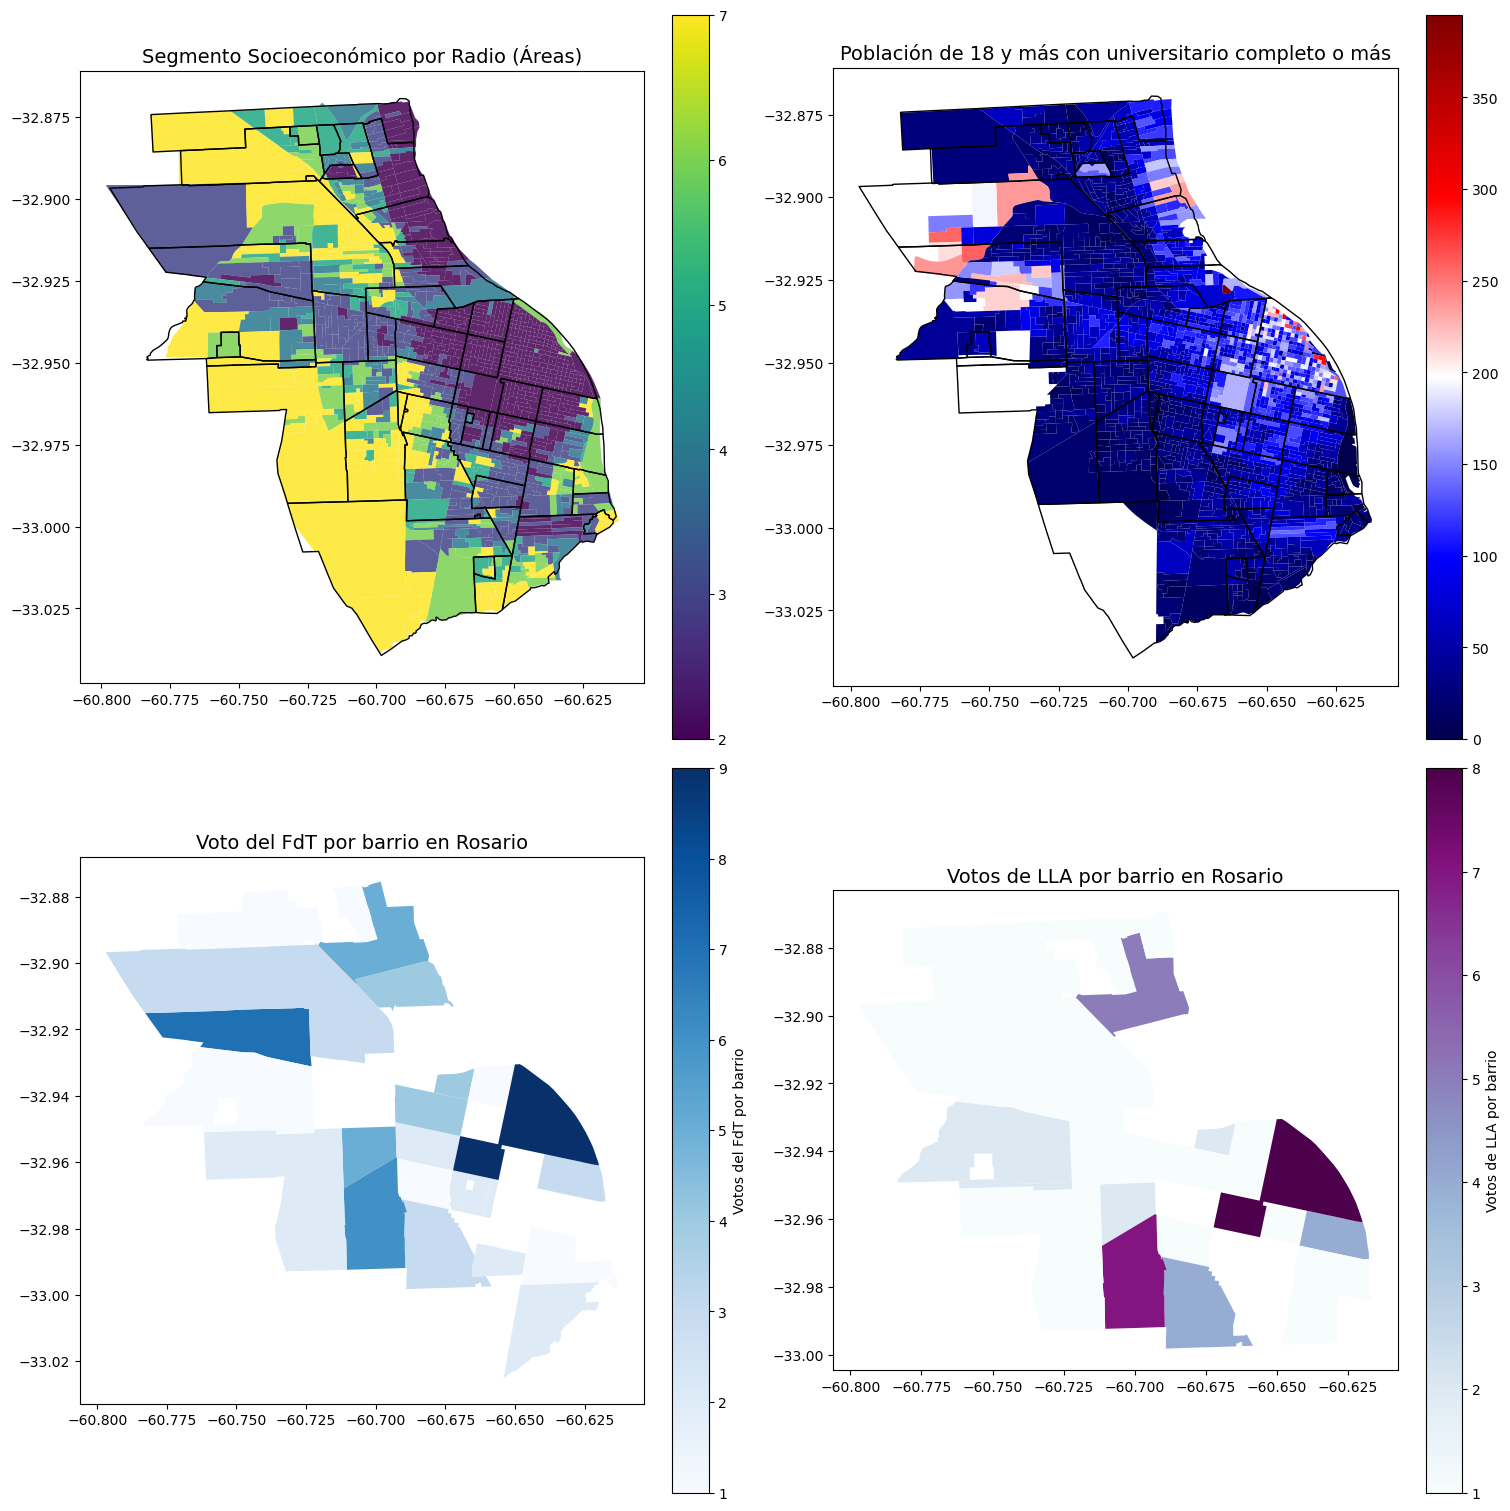

In [325]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15), constrained_layout=True)
barrios.plot(column='cantidad_votos_fdt', ax=axes[1,0], legend=True, cmap='Blues', legend_kwds={'label': "Votos del FdT por barrio"})
axes[1,0].set_title('Voto del FdT por barrio en Rosario', fontsize=14)
estratos.plot(column='Segmento socioeconómico del radio', ax=axes[0,0], legend=True, cmap='viridis', alpha=0.85)
barrios.boundary.plot(ax=axes[0,0],edgecolor='black',linewidth=1)
axes[0,0].set_title('Segmento Socioeconómico por Radio (Áreas)', fontsize=14)
niveleducativo.plot(column='Población de 18 y más con universitario completo o más', ax=axes[0,1], legend=True, cmap='seismic', alpha=1)  # alpha controla la opacidad del área
axes[0,1].set_title('Población de 18 y más con universitario completo o más', fontsize=14)
barrios.boundary.plot(ax=axes[0,1],edgecolor='black',linewidth=1)
barrios.plot(column='cantidad_votos_lib', ax=axes[1,1], legend=True, cmap='BuPu', legend_kwds={'label': "Votos de LLA por barrio"})
axes[1,1].set_title('Votos de LLA por barrio en Rosario', fontsize=14)
plt.show()

Text(0.5, 1.0, 'Población de 18 y más con universitario completo o más')

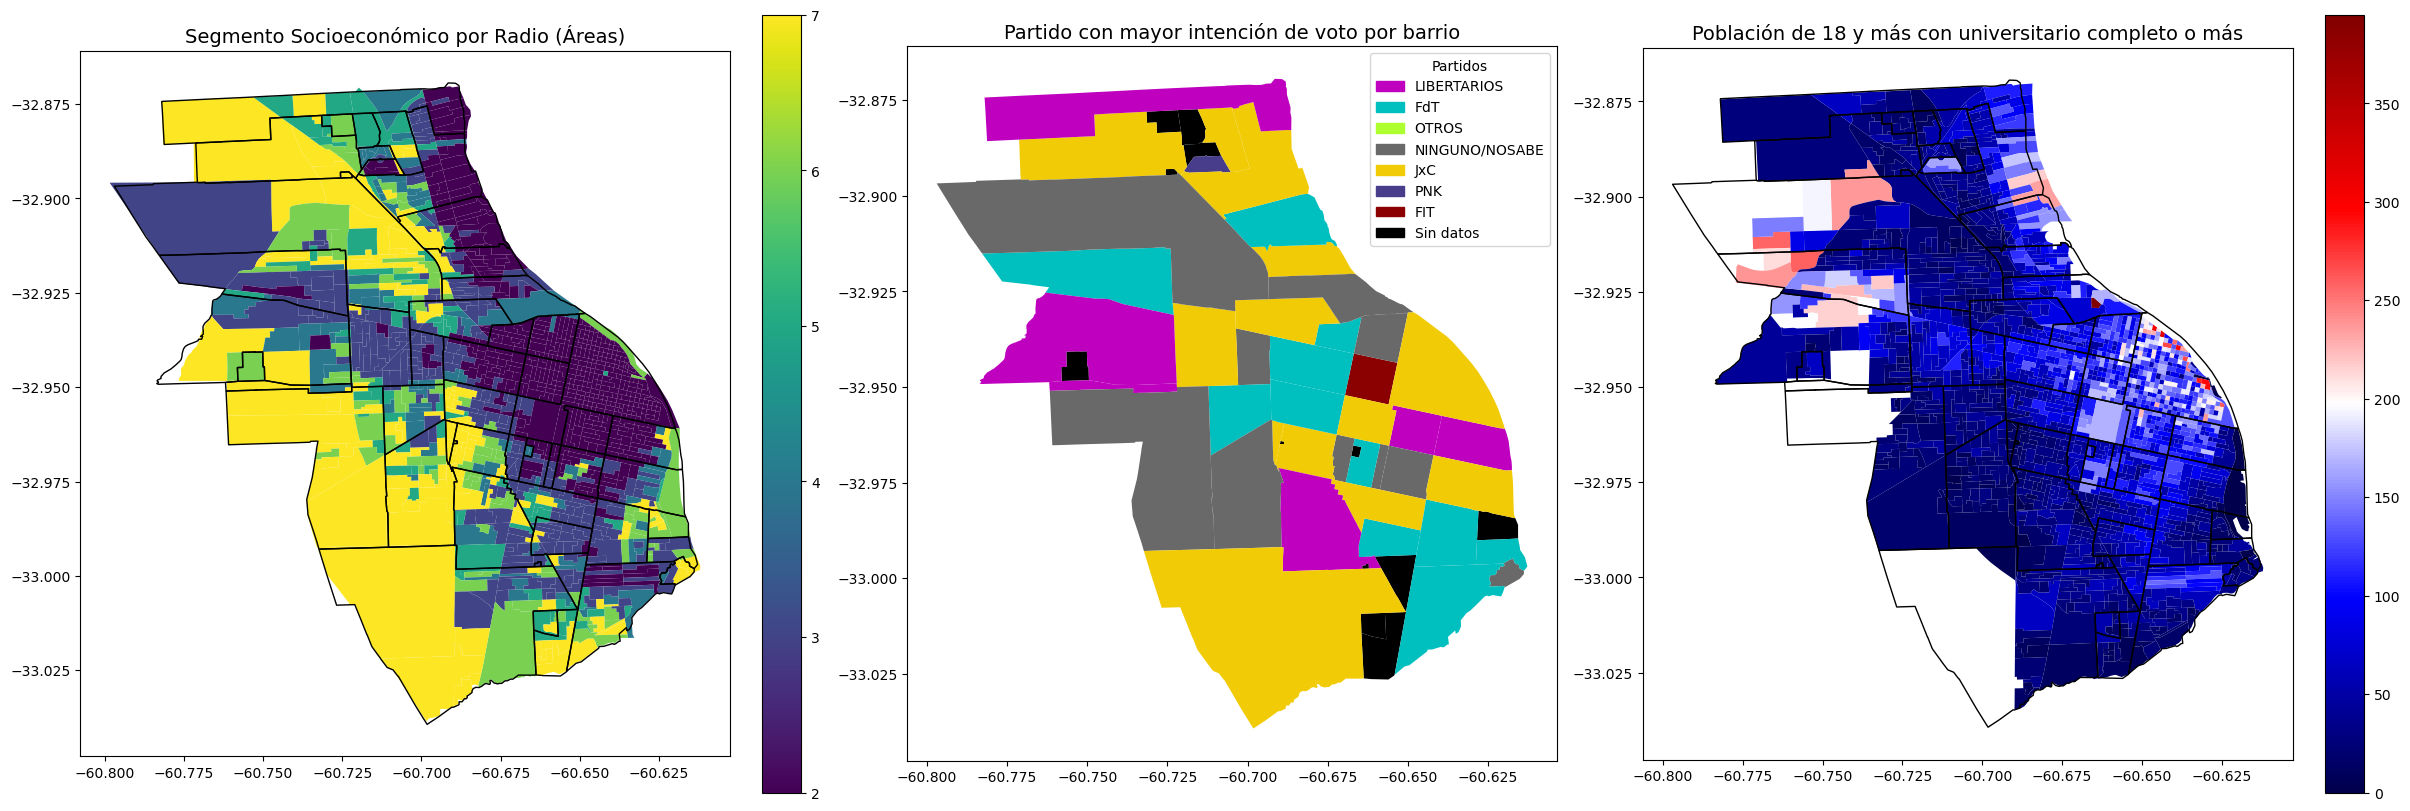

In [326]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8), constrained_layout=True)
estratos.plot(column='Segmento socioeconómico del radio', ax=axes[0], legend=True, cmap='viridis', alpha=1)
barrios.boundary.plot(ax=axes[0],edgecolor='black',linewidth=1)
axes[0].set_title('Segmento Socioeconómico por Radio (Áreas)', fontsize=14)
barrios.plot(color=barrios['color'], ax=axes[1])
axes[1].set_title('Partido con mayor intención de voto por barrio', fontsize=14)
leyenda = [mpatches.Patch(color=color, label=partido) for partido, color in colores_partidos.items()]
leyenda.append(mpatches.Patch(color='black', label='Sin datos'))
axes[1].legend(handles=leyenda, title='Partidos', loc='upper right', fontsize=10)
niveleducativo.plot(column='Población de 18 y más con universitario completo o más', ax=axes[2], legend=True, cmap='seismic', alpha=1)
barrios.boundary.plot(ax=axes[2],edgecolor='black',linewidth=1)
axes[2].set_title('Población de 18 y más con universitario completo o más', fontsize=14)

In [327]:
pobreza['Geometría en GeoJSON'] = pobreza['Geometría en GeoJSON'].apply(lambda x: shape(json.loads(x)))
pobreza=pobreza.set_geometry('Geometría en GeoJSON')
pobreza=gpd.GeoDataFrame(pobreza, geometry='Geometría en GeoJSON', crs='EPSG:4326')
pobreza = pobreza.dropna(subset=['Latitud del centroide', 'Longitud del centroide'])
pobreza = pobreza.dropna(subset=['Nivel de incidencia de pobreza crónica'])
pobreza = pobreza.dropna(subset=['Geometría en GeoJSON'])
pobreza['Nivel de incidencia de pobreza crónica'] = pobreza['Nivel de incidencia de pobreza crónica'].astype(int)

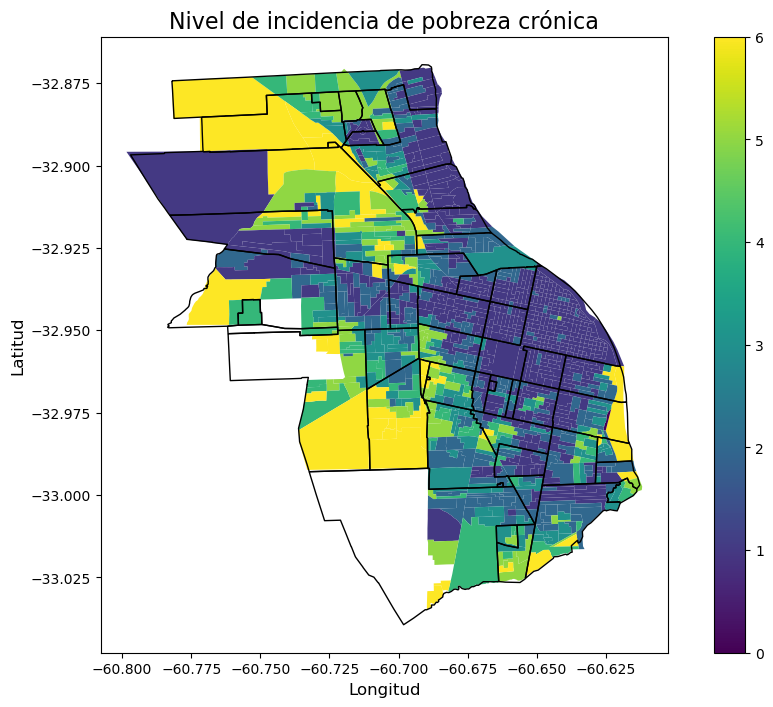

In [328]:
fig, ax = plt.subplots(figsize=(12, 8))
pobreza.plot(column='Nivel de incidencia de pobreza crónica', ax=ax, legend=True, cmap='viridis', alpha=1)
ax.set_title('Nivel de incidencia de pobreza crónica', fontsize=16)
ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)
barrios.boundary.plot(ax=ax,edgecolor='black',linewidth=1)
plt.show()

Text(0.5, 1.0, 'Votos de LLA por barrio en Rosario')

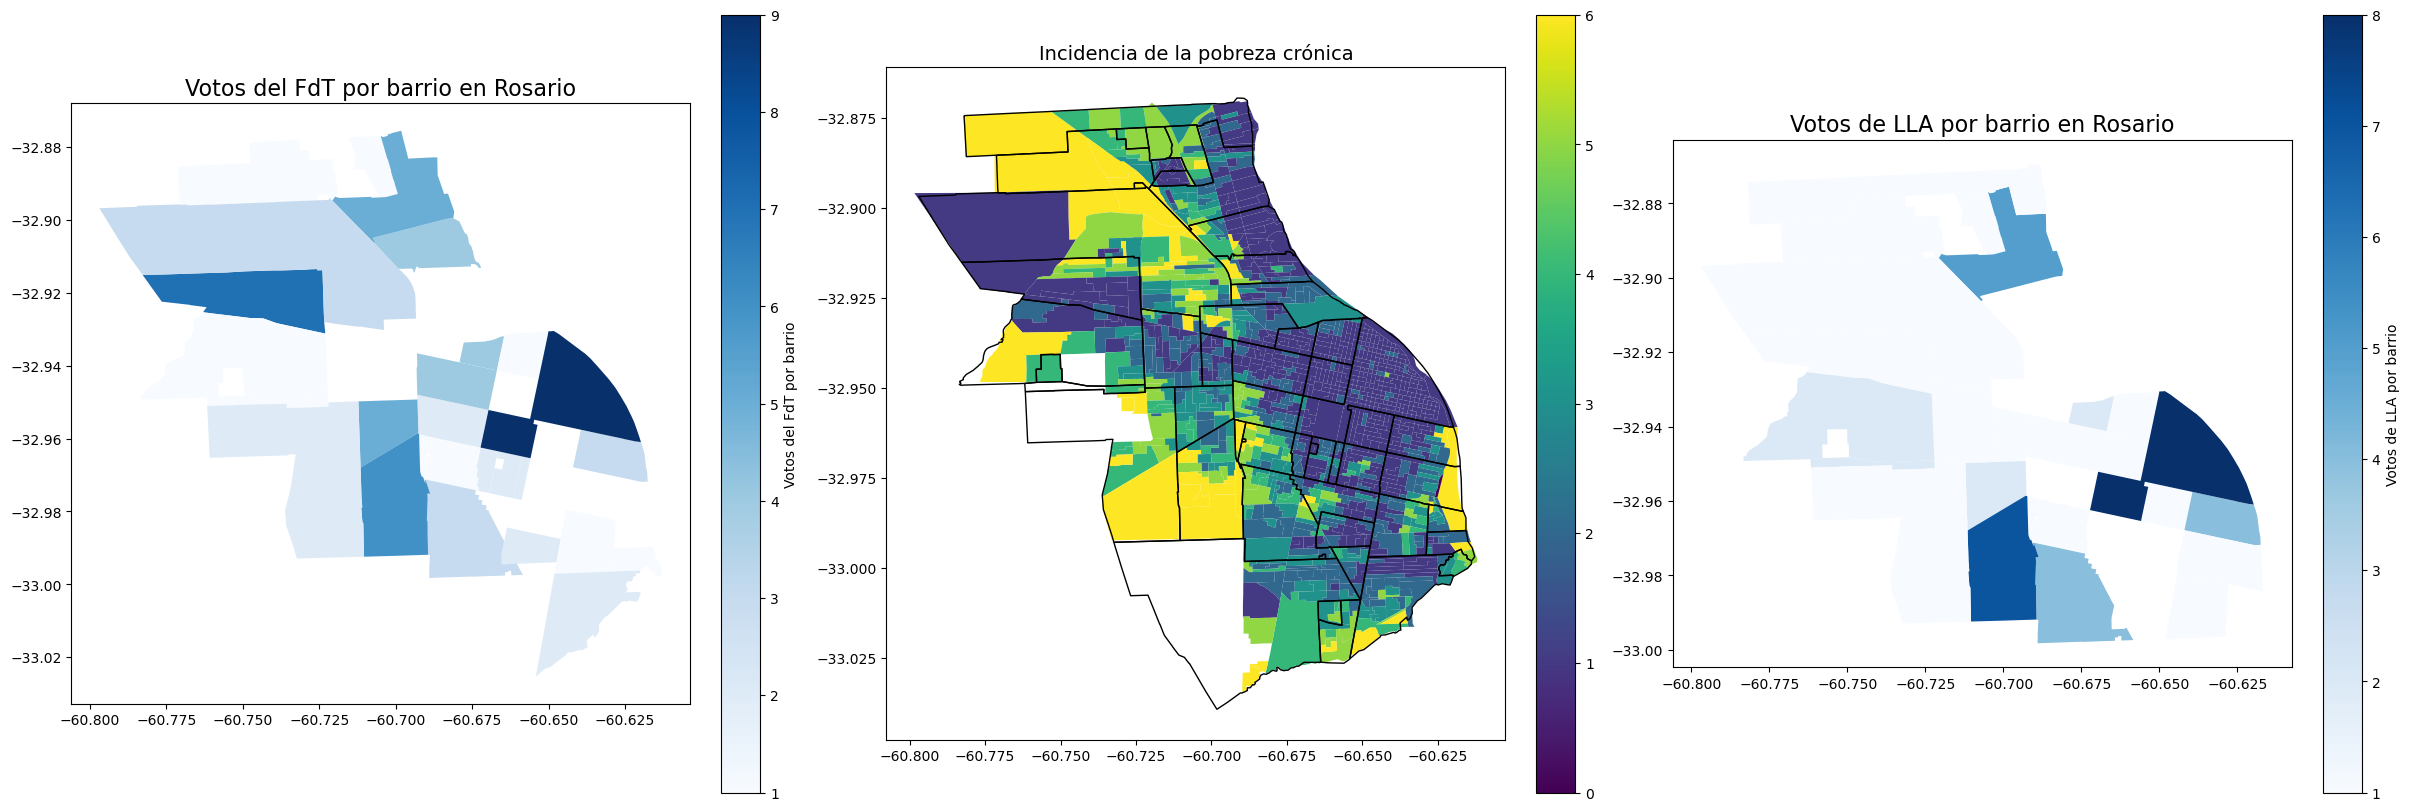

In [329]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8), constrained_layout=True)
barrios.plot(column='cantidad_votos_fdt', ax=axes[0], legend=True, cmap='Blues', legend_kwds={'label': "Votos del FdT por barrio"})
axes[0].set_title('Votos del FdT por barrio en Rosario', fontsize=16)
pobreza.plot(column='Nivel de incidencia de pobreza crónica', ax=axes[1], legend=True, cmap='viridis', alpha=1)
axes[1].set_title('Incidencia de la pobreza crónica', fontsize=14)
barrios.boundary.plot(ax=axes[1],edgecolor='black',linewidth=1)
barrios.plot(column='cantidad_votos_lib', ax=axes[2], legend=True, cmap='Blues', legend_kwds={'label': "Votos de LLA por barrio"})
axes[2].set_title('Votos de LLA por barrio en Rosario', fontsize=16)

In [330]:
df['VOTO_LIBERTARIOS'] = df['INT DE VOTO X ESPACIO'].apply(lambda x: 1 if x == 'LIBERTARIOS' else 0)
df['GENERO'] = df['GENERO'] == 'Masculino' 


In [331]:
df['VOTO_LIBERTARIOS'] = pd.to_numeric(df['VOTO_LIBERTARIOS'], errors='coerce')
df['GENERO'] = df['GENERO'].astype(int)
df = df.dropna(subset=['VOTO_LIBERTARIOS', 'GENERO'])

X = df[['GENERO']]  
y = df['VOTO_LIBERTARIOS']

# Añadir una constante (intercepto) a las variables independientes
X = sm.add_constant(X)

# Ajustar el modelo de regresión logística
model = sm.Logit(y, X)

# Ajustar el modelo
result = model.fit()

# Mostrar los resultados del modelo
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.398599
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:       VOTO_LIBERTARIOS   No. Observations:                  313
Model:                          Logit   Df Residuals:                      311
Method:                           MLE   Df Model:                            1
Date:               vie, 05 sept 2025   Pseudo R-squ.:                 0.06975
Time:                        11:08:25   Log-Likelihood:                -124.76
converged:                       True   LL-Null:                       -134.12
Covariance Type:            nonrobust   LLR p-value:                 1.523e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7154      0.344     -7.889      0.000      -3.390      -2.041
GENERO         1.5192      0.

Analisis de regresion entre la variable GENERO y la posibilidad de votar a los libertarios
El coeficiente para la variable GENERO da 1.5192. Esto muestra que los hombres tienen un aumento en las probabilidades de votar por LLA. 
El valor P para GENERO es 0, lo que significa que el efecto de la variable sobre la probabilidad de votar por LLA es alta.
El valor P para la constante es 0, lo que significa que el intercepto es significativo.
Los intervalos de confianza para la constante y para la variable genero estan por encima de 0, lo que indica que el genero (masculino) tiene un impacto positivo y significativo en el voto a los libertarios.
El pseudo R cuadrado es 0.06975, lo que indica que el modelo explica aproximadamente el 6.98% de la variabilidad en la variable dependiente (VOTO_LIBERTARIOS).


In [332]:
df['VOTO_FIT'] = df['INT DE VOTO X ESPACIO'].apply(lambda x: 1 if x == 'FIT' else 0)
df_filtrado = df[df['EDAD'] == '26 a 35']
print(df.head())

   Unnamed: 0 interview__key METODO  Coord1__Latitude  Coord1__Longitude  \
0           0    56-56-25-81    F2F        -32.881458         -60.695274   
1           1    67-96-98-06    F2F        -32.882259         -60.693571   
2           2    24-21-01-39    F2F        -32.884731         -60.692882   
3           3    84-96-80-81    F2F        -32.884673         -60.693464   
4           4    21-29-79-64    F2F        -32.918833         -60.703628   

       EDAD  GENERO INT DE VOTO X ESPACIO      RADIO  \
0  56 y mas       1           LIBERTARIOS  820840409   
1   36 a 45       1                 OTROS  820840410   
2  56 y mas       0                 OTROS  820840502   
3   26 a 35       1           LIBERTARIOS  820840502   
4   36 a 45       0        NINGUNO/NOSABE  820841013   

                                       geometry    color  VOTO_LIBERTARIOS  \
0  POINT (-60.6952736992389 -32.88145751226693)  #BF00BF                 1   
1  POINT (-60.6935706641525 -32.88225878030062)  #

In [333]:
df['VOTO_FIT'] = pd.to_numeric(df['VOTO_FIT'], errors='coerce')
df['rango_26_35'] = df['EDAD'] == '26 a 35'
df['rango_26_35'] = df['rango_26_35'].astype(int)
print(df)

     Unnamed: 0 interview__key METODO  Coord1__Latitude  Coord1__Longitude  \
0             0    56-56-25-81    F2F        -32.881458         -60.695274   
1             1    67-96-98-06    F2F        -32.882259         -60.693571   
2             2    24-21-01-39    F2F        -32.884731         -60.692882   
3             3    84-96-80-81    F2F        -32.884673         -60.693464   
4             4    21-29-79-64    F2F        -32.918833         -60.703628   
..          ...            ...    ...               ...                ...   
308         367   347615540259    IVR        -32.941000         -60.688295   
309         368   347615540658    IVR        -32.970114         -60.653051   
310         369   347615672682    IVR        -32.907759         -60.752721   
311         370   348715470373    IVR        -32.942161         -60.639935   
312         371   387154502466    IVR        -32.957100         -60.637709   

         EDAD  GENERO INT DE VOTO X ESPACIO      RADIO  \
0    

In [334]:
X = df[['rango_26_35']]  # Variables independientes
y = df['VOTO_FIT']  # Variable dependiente (asegúrate de que esta columna sea binaria)

# Añadir una constante (intercepto) a las variables independientes
X = sm.add_constant(X)

# Ajustar el modelo de regresión logística
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.139305
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               VOTO_FIT   No. Observations:                  313
Model:                          Logit   Df Residuals:                      311
Method:                           MLE   Df Model:                            1
Date:               vie, 05 sept 2025   Pseudo R-squ.:                 0.01518
Time:                        11:08:26   Log-Likelihood:                -43.602
converged:                       True   LL-Null:                       -44.275
Covariance Type:            nonrobust   LLR p-value:                    0.2463
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.6032      0.383     -9.406      0.000      -4.354      -2.852
rango_26_35     0.8731    

### Resultados de regresión logística  

- **Variable dependiente:** probabilidad de votar al FIT.  
- **Variables explicativas:** pertenencia al rango etario 26–35 años (vs. grupo base).

**Principales hallazgos:**  
- El grupo de referencia (fuera de 26–35 años) tiene una probabilidad estimada de 2,7% de votar al FIT. 
- Las personas de 26–35 años presentan odds de voto 2,4 veces mayores, lo que se traduce en una probabilidad estimada de 6,1%
- Sin embargo, la diferencia no es estadísticamente significativa (p = 0.218).

In [335]:
dummies = pd.get_dummies(df["INT DE VOTO X ESPACIO"], prefix="INT DE VOTO X ESPACIO")
df = pd.concat([df, dummies], axis=1)

In [336]:
dummies = pd.get_dummies(df["EDAD"], prefix="EDAD")
df = pd.concat([df, dummies], axis=1)

In [337]:
estratos=gpd.read_file('https://github.com/BiancaDiFranco/M-todosOP/raw/refs/heads/main/Trabajo%20final/datasets%20complementarios/poblaciones/Estratificaci%C3%B3n%20de%20radios%20censales%20-%20Rosario.csv')
estratos['Geometría en GeoJSON'] = estratos['Geometría en GeoJSON'].apply(lambda x: shape(json.loads(x)))
estratos=estratos.set_geometry('Geometría en GeoJSON')
estratos=gpd.GeoDataFrame(estratos, geometry='Geometría en GeoJSON', crs='EPSG:4326')
estratos = estratos.dropna(subset=['Latitud del centroide', 'Longitud del centroide'])
estratos = estratos.dropna(subset=["Segmento socioeconómico del radio"])
estratos = estratos.dropna(subset=['Geometría en GeoJSON'])

In [338]:
geometry = [Point(xy) for xy in zip(df['Coord1__Longitude'], df['Coord1__Latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry)
gdf.set_crs('EPSG:4326', inplace=True)
union=gpd.sjoin(gdf, estratos, how='inner', predicate='within')
union['Hogares con hacinamiento (>= 3 personas por cuarto)']

0       0
1       0
2      15
3      15
4      21
       ..
308     1
309     0
310     6
311     0
312     0
Name: Hogares con hacinamiento (>= 3 personas por cuarto), Length: 313, dtype: object

In [339]:
union['Segmento socioeconómico del radio']=union['Segmento socioeconómico del radio'].astype(int)
union['Hogares con jefatura femenina']= union['Hogares con jefatura femenina'].astype(int)

In [340]:
X = union[['GENERO','Hogares con jefatura femenina']]
y = union['INT DE VOTO X ESPACIO_LIBERTARIOS']   
X = sm.add_constant(X)

In [341]:
model = sm.Logit(y, X)
results = model.fit()  

print(results.summary())

Optimization terminated successfully.
         Current function value: 0.398270
         Iterations 7
                                   Logit Regression Results                                  
Dep. Variable:     INT DE VOTO X ESPACIO_LIBERTARIOS   No. Observations:                  313
Model:                                         Logit   Df Residuals:                      310
Method:                                          MLE   Df Model:                            2
Date:                              vie, 05 sept 2025   Pseudo R-squ.:                 0.07051
Time:                                       11:08:35   Log-Likelihood:                -124.66
converged:                                      True   LL-Null:                       -134.12
Covariance Type:                           nonrobust   LLR p-value:                 7.814e-05
                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

In [342]:
union['Hogares con al menos un indicador NBI']=union['Hogares con al menos un indicador NBI'].astype(int)
union['Hogares con hacinamiento (>= 3 personas por cuarto)']=union['Hogares con hacinamiento (>= 3 personas por cuarto)'].astype(int)
union['Hogares con indicadores de alta marginalidad']=union['Hogares con indicadores de alta marginalidad'].astype(int)
union['Población de 18 a 29 que no estudia ni trabaja']=union['Población de 18 a 29 que no estudia ni trabaja'].astype(int)
union['Jefes sin secundaria completa']=union['Jefes sin secundaria completa'].astype(int)
union['Hogares con computadora']=union['Hogares con computadora'].astype(int)

In [343]:
X = union[['Hogares con al menos un indicador NBI','Hogares con hacinamiento (>= 3 personas por cuarto)','Hogares con indicadores de alta marginalidad','Segmento socioeconómico del radio','Población de 18 a 29 que no estudia ni trabaja']]
y = union['INT DE VOTO X ESPACIO_FdT']   
X = sm.add_constant(X)
model = sm.Logit(y, X)
results = model.fit()  

print(results.summary())

Optimization terminated successfully.
         Current function value: 0.527601
         Iterations 6
                               Logit Regression Results                              
Dep. Variable:     INT DE VOTO X ESPACIO_FdT   No. Observations:                  313
Model:                                 Logit   Df Residuals:                      307
Method:                                  MLE   Df Model:                            5
Date:                      vie, 05 sept 2025   Pseudo R-squ.:                 0.01462
Time:                               11:08:35   Log-Likelihood:                -165.14
converged:                              True   LL-Null:                       -167.59
Covariance Type:                   nonrobust   LLR p-value:                    0.4284
                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [344]:
X = union[['Hogares con al menos un indicador NBI','Hogares con hacinamiento (>= 3 personas por cuarto)','Hogares con indicadores de alta marginalidad','Segmento socioeconómico del radio','Población de 18 a 29 que no estudia ni trabaja']]
y = union['INT DE VOTO X ESPACIO_FIT']   
X = sm.add_constant(X)
model = sm.Logit(y, X)
results = model.fit()  

print(results.summary())

Optimization terminated successfully.
         Current function value: 0.128886
         Iterations 12
                               Logit Regression Results                              
Dep. Variable:     INT DE VOTO X ESPACIO_FIT   No. Observations:                  313
Model:                                 Logit   Df Residuals:                      307
Method:                                  MLE   Df Model:                            5
Date:                      vie, 05 sept 2025   Pseudo R-squ.:                 0.08884
Time:                               11:08:35   Log-Likelihood:                -40.341
converged:                              True   LL-Null:                       -44.275
Covariance Type:                   nonrobust   LLR p-value:                    0.1637
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [345]:
X = union[['Segmento socioeconómico del radio','Población de 18 a 29 que no estudia ni trabaja','Jefes sin secundaria completa','Hogares con computadora']]
y = union['INT DE VOTO X ESPACIO_LIBERTARIOS']   
X = sm.add_constant(X)
model = sm.Logit(y, X)
results = model.fit()  

print(results.summary())

Optimization terminated successfully.
         Current function value: 0.425439
         Iterations 6
                                   Logit Regression Results                                  
Dep. Variable:     INT DE VOTO X ESPACIO_LIBERTARIOS   No. Observations:                  313
Model:                                         Logit   Df Residuals:                      308
Method:                                          MLE   Df Model:                            4
Date:                              vie, 05 sept 2025   Pseudo R-squ.:                0.007107
Time:                                       11:08:35   Log-Likelihood:                -133.16
converged:                                      True   LL-Null:                       -134.12
Covariance Type:                           nonrobust   LLR p-value:                    0.7530
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

In [346]:
union['Población de 18 y más hasta primaria']=union['Población de 18 y más hasta primaria'].astype(int)
union['Población de 18 y más con primaria y secundario completo']=union['Población de 18 y más con primaria y secundario completo'].astype(int)
union['Población de 18 y más con secundario completo o terciario sin universitario completo']=union['Población de 18 y más con secundario completo o terciario sin universitario completo'].astype(int)
union['Población con universitario completo o más']=union['Población con universitario completo o más'].astype(int)

In [347]:
X = union[['Población de 18 y más con primaria y secundario completo','Población de 18 y más hasta primaria','Población de 18 y más con secundario completo o terciario sin universitario completo', 'Población con universitario completo o más']]
y = union['INT DE VOTO X ESPACIO_JxC']
X = sm.add_constant(X)
model = sm.Logit(y, X)
results = model.fit()  

print(results.summary())

Optimization terminated successfully.
         Current function value: 0.550254
         Iterations 6
                               Logit Regression Results                              
Dep. Variable:     INT DE VOTO X ESPACIO_JxC   No. Observations:                  313
Model:                                 Logit   Df Residuals:                      308
Method:                                  MLE   Df Model:                            4
Date:                      vie, 05 sept 2025   Pseudo R-squ.:                0.007298
Time:                               11:08:35   Log-Likelihood:                -172.23
converged:                              True   LL-Null:                       -173.50
Covariance Type:                   nonrobust   LLR p-value:                    0.6388
                                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

In [348]:
X = union[['Población de 18 y más hasta primaria','Población de 18 y más con primaria y secundario completo','Población de 18 y más con secundario completo o terciario sin universitario completo', 'Población con universitario completo o más']]
y = union['INT DE VOTO X ESPACIO_FdT']
X = sm.add_constant(X)
model = sm.Logit(y, X)
results = model.fit()  

print(results.summary())

Optimization terminated successfully.
         Current function value: 0.530205
         Iterations 5
                               Logit Regression Results                              
Dep. Variable:     INT DE VOTO X ESPACIO_FdT   No. Observations:                  313
Model:                                 Logit   Df Residuals:                      308
Method:                                  MLE   Df Model:                            4
Date:                      vie, 05 sept 2025   Pseudo R-squ.:                0.009752
Time:                               11:08:36   Log-Likelihood:                -165.95
converged:                              True   LL-Null:                       -167.59
Covariance Type:                   nonrobust   LLR p-value:                    0.5139
                                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

In [349]:
X = union[['Población de 18 y más hasta primaria','Población de 18 y más con primaria y secundario completo','Población de 18 y más con secundario completo o terciario sin universitario completo', 'Población con universitario completo o más']]
y = union['INT DE VOTO X ESPACIO_NINGUNO/NOSABE']
X = sm.add_constant(X)
model = sm.Logit(y, X)
results = model.fit()  

print(results.summary())

Optimization terminated successfully.
         Current function value: 0.496997
         Iterations 6
                                    Logit Regression Results                                    
Dep. Variable:     INT DE VOTO X ESPACIO_NINGUNO/NOSABE   No. Observations:                  313
Model:                                            Logit   Df Residuals:                      308
Method:                                             MLE   Df Model:                            4
Date:                                 vie, 05 sept 2025   Pseudo R-squ.:                 0.01030
Time:                                          11:08:36   Log-Likelihood:                -155.56
converged:                                         True   LL-Null:                       -157.18
Covariance Type:                              nonrobust   LLR p-value:                    0.5189
                                                                                           coef    std err          z     

In [350]:
X = union[['Población de 18 y más hasta primaria','Población de 18 y más con primaria y secundario completo','Población de 18 y más con secundario completo o terciario sin universitario completo', 'Población con universitario completo o más']]
y = union['INT DE VOTO X ESPACIO_LIBERTARIOS']
X = sm.add_constant(X)
model = sm.Logit(y, X)
results = model.fit()  

print(results.summary())

Optimization terminated successfully.
         Current function value: 0.426189
         Iterations 6
                                   Logit Regression Results                                  
Dep. Variable:     INT DE VOTO X ESPACIO_LIBERTARIOS   No. Observations:                  313
Model:                                         Logit   Df Residuals:                      308
Method:                                          MLE   Df Model:                            4
Date:                              vie, 05 sept 2025   Pseudo R-squ.:                0.005356
Time:                                       11:08:36   Log-Likelihood:                -133.40
converged:                                      True   LL-Null:                       -134.12
Covariance Type:                           nonrobust   LLR p-value:                    0.8378
                                                                                           coef    std err          z      P>|z|      [0.025      

## Conclusiones

El análisis de la encuesta georreferenciada en Rosario (octubre 2023) muestra un escenario de **competencia fragmentada**: Juntos por el Cambio y el Frente de Todos concentraron las mayores preferencias, mientras que La Libertad Avanza emergió con un nivel de apoyo relevante. La presencia de un **20% de indecisos** destaca la volatilidad electoral en el momento de la medición.

Los modelos estimados sugieren que la **intención de voto no se explica de manera robusta por variables sociodemográficas clásicas**. Se observaron algunas asociaciones puntuales —como un mayor apoyo a LLA entre los hombres y al FIT en los segmentos más jóvenes— pero el bajo poder explicativo de los modelos indica que otros factores, no capturados en esta encuesta, incidieron en la decisión de voto. Este hallazgo resulta relevante en la medida en que evidencia la dificultad de identificar patrones estructurales en un contexto político signado por el hartazgo y la demanda de cambio.

En conjunto, los resultados deben interpretarse como **descriptivos y exploratorios**. Más que perfilar electorados definidos, el análisis muestra los límites de los enfoques puramente sociodemográficos y señala la necesidad de incorporar variables de percepción política, confianza en las instituciones, evaluación económica y liderazgo para mejorar la capacidad explicativa. Así, el estudio constituye un ejercicio de aplicación metodológica y de reflexión sobre la relación entre contexto coyuntural y comportamiento electoral.
